# **DATASCI18 (THESIS 2)**
> ***(RF)***
#  
> *Detection and Classification of Panic Attack Occurrence and Severity Using Hybrid Artificial Neural Network and Random Forest (ANN-RF) Model with Explainable Artificial Intelligence (XAI)*

### **FLOW**

### 1. Data Loading
- Import training and testing datasets (`Panic_Disorder_training.csv` and `Panic_Disorder_testing.csv`).
- Verify that the train–test split is balanced by comparing the class distribution of the target variable (Panic Disorder Diagnosis) in both datasets.
---
### 2. Exploratory Data Analysis (EDA)
- Inspect dataset structure (shape, head, column data types).
- Check for missing values
- Visualizations:
  - Histogram and Boxplot for numerical variable
  - Count plots for categorical variables (Gender, Family History, Severity, etc.).
---
### **3. Data Preprocessing and Feature Engineering**
- **Handling Missing Values**
  - Median imputation for numeric columns.  
  - Mode imputation for categorical columns.  
- **Feature Engineering**
  - Drop non-predictive column (`Participant ID`).  
  - Create **Panic Attack Occurrence**, **Panic Attack Occurrence Prob**, **Predicted Severity**, **Severity Confidence**  
  
- **Filtering for Severity Prediction**
  - Subset data to include only samples with `Panic Disorder Diagnosis = 1`.  
  - Apply **Label Encoding** to categorical target variables.  
  - Apply **One-Hot Encoding** for categorical predictors.  
  - Use **Min-Max Scaling** for numeric features to normalize values within [0,1].     
---
### **4. Model Training**
#### **4.1 Random Forest — Occurrence Model**
- **Target Variable:** `Panic Disorder Diagnosis` (binary classification).  
- **Input Features:** Six top predictors — *Medical History, Lifestyle Factors, Symptoms, Current Stressors, Coping Mechanisms, Personal History*.  
- **Configuration:**
  - Parameters: `n_estimators=500`, `max_depth=None`, `max_features='sqrt'`, `min_samples_leaf=12`, `class_weight='balanced'`.  
  - Validation split used for F1-optimized threshold tuning.  
  - Outputs: Accuracy, Precision, Recall, F1-score, ROC-AUC, and training time.  

#### **4.2 Random Forest — Severity Model**
- **Target Variable:** `Severity` (normalized to *Mild, Moderate, Severe*).  
- **Input Features:** Same six features as occurrence (only for `Panic Disorder Diagnosis = 1`).  
- **Configuration:**
  - Multiclass Random Forest classifier with balanced class weights.  
  - Parameters: `n_estimators=400`, `max_depth=None`, `max_features='sqrt'`, `min_samples_leaf=12`, `class_weight='balanced'`.  
  - Outputs: Accuracy, macro-Precision, macro-Recall, macro-F1, macro ROC-AUC, and training time.  
---
### **5. Model Evaluation and Comparison**
- **Performance Metrics:**
  - Accuracy  
  - Precision  
  - Recall  
  - F1-score  
  - ROC-AUC  
- **Visualizations:**
  - Confusion Matrices  
  - ROC Curves  
  - Feature Importance plots  
  - Training time comparison  
---
### **6. Explainable AI (XAI)**
- **Global Interpretability:**  
  - Use **SHAP** to identify which features contribute most to predictions.  
- **Local Interpretability:**  
  - Use **LIME** to explain individual classification decisions.  
- **Key Features Identified:**  
  - *Symptoms, Current Stressors, Psychiatric and Medical History, Lifestyle Factors, and Coping Mechanisms.*  
---

### **DATASET DETAILS:** `Panic Disorder Detection Dataset`

***Data Features (17 columns):***  

- **Participant ID**: Unique identifier assigned to each participant.  
- **Age**: Participant’s age at the time of data collection.  
- **Gender**: Participant’s gender.  
- **Family History**: Presence of panic disorder or other mental health conditions in the participant’s family.  
- **Personal History**: Participant’s past experiences relevant to mental health.  
- **Current Stressors**: Present life stressors that may impact mental health.  
- **Symptoms**: Reported symptoms experienced by the participant.  
- **Severity**: Extent of severity of the reported symptoms.  
- **Impact on Life**: Degree to which symptoms affect daily functioning (work, relationships, etc.).  
- **Demographics**: Participant’s demographic characteristics.  
- **Medical History**: General medical background of the participant.  
- **Psychiatric History**: Participant’s history of psychiatric conditions.  
- **Substance Use**: Information on the participant’s substance use.  
- **Coping Mechanisms**: Strategies employed to manage stress or panic disorder symptoms.  
- **Social Support**: Quantity and quality of social support (family, friends, support groups).  
- **Lifestyle Factors**: Lifestyle aspects (sleep, diet, physical activity) influencing mental health.  
- **Panic Disorder Diagnosis**: Target variable indicating presence or absence of panic disorder.  

In [1]:
# Add all necesarry imports
import pandas as pd
import csv
import numpy as np
import csv as reader
import random, time, tensorflow as tf
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, ConfusionMatrixDisplay, log_loss, auc
from tensorflow.keras.models import Model
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve, KFold, train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_predict
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
from scipy.stats import randint
import time
from sklearn.pipeline import Pipeline, make_pipeline

# -------- EXPLAINABLE AI (XAI) --------
# import shap
# import lime
# import lime.lime_tabular
import matplotlib.pyplot as plt
import seaborn as sns
# from lime.lime_tabular import LimeTabularExplainer
# Reproducibility
# np.random.seed(42); random.seed(42); tf.random.set_seed(42)

## ***1. Load the dataset***

## ***Count "None" as Actual Values***

In [2]:
df = pd.read_csv("df.csv")

### Print basic information

In [3]:
print("Dataset Info Training:")
print(df.info())

print("\nDataset Description(including all columns):")
print(df.describe(include='all'))

Dataset Info Training:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10713 entries, 0 to 10712
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Participant ID            10713 non-null  int64 
 1   Age                       10713 non-null  int64 
 2   Gender                    10713 non-null  object
 3   Family History            10713 non-null  object
 4   Personal History          10713 non-null  object
 5   Current Stressors         10713 non-null  object
 6   Symptoms                  10713 non-null  object
 7   Severity                  10713 non-null  object
 8   Impact on Life            10713 non-null  object
 9   Demographics              10713 non-null  object
 10  Medical History           8401 non-null   object
 11  Psychiatric History       8273 non-null   object
 12  Substance Use             7440 non-null   object
 13  Coping Mechanisms         10713 non-null  object
 14 

### Check for missing values and duplicate entries

In [4]:
# Check for missing values in the testing dataset
print("\nMissing values in dataset:")
print(df.isnull().sum())


Missing values in dataset:
Participant ID                 0
Age                            0
Gender                         0
Family History                 0
Personal History               0
Current Stressors              0
Symptoms                       0
Severity                       0
Impact on Life                 0
Demographics                   0
Medical History             2312
Psychiatric History         2440
Substance Use               3273
Coping Mechanisms              0
Social Support                 0
Lifestyle Factors              0
Panic Disorder Diagnosis       0
Composite_Severity_Index       0
Severity_Category              0
dtype: int64


In [5]:
print("Number of Duplicate Rows")
print(df.duplicated().sum())

Number of Duplicate Rows
0


## ***No Actual Empty Values, String "None" are being counted as nan***

In [6]:
# Count the number of "None" entries in the specified columns
columns_to_check = ["Medical History", "Psychiatric History", "Substance Use", "Composite_Severity_Index", "Severity_Category"]

for column in columns_to_check:
    print(f"Unique values in column {column}:")
    print(df[column].unique())
    print("\n")


Unique values in column Medical History:
['Diabetes' 'Asthma' nan 'Heart disease']


Unique values in column Psychiatric History:
[nan 'Depressive disorder' 'Bipolar disorder' 'Anxiety disorder']


Unique values in column Substance Use:
['Drugs' nan 'Alcohol']


Unique values in column Composite_Severity_Index:
[12 14  7 15 10  5 13  8  6  9 11 16  4]


Unique values in column Severity_Category:
['Moderately ill' 'Markedly ill' 'Mildly ill' 'Borderline ill']




## ***Count "None" as Actual Values***

In [7]:
df = pd.read_csv("df.csv", na_values=["", " "], keep_default_na=False)

## ***2. Exploratory Data Analysis (EDA)***

In [8]:
# Inspect dataset structure
print("Dataset shape:", df.shape)

print("\nDataset info:")
print(df.info())

Dataset shape: (10713, 19)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10713 entries, 0 to 10712
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Participant ID            10713 non-null  int64 
 1   Age                       10713 non-null  int64 
 2   Gender                    10713 non-null  object
 3   Family History            10713 non-null  object
 4   Personal History          10713 non-null  object
 5   Current Stressors         10713 non-null  object
 6   Symptoms                  10713 non-null  object
 7   Severity                  10713 non-null  object
 8   Impact on Life            10713 non-null  object
 9   Demographics              10713 non-null  object
 10  Medical History           8401 non-null   object
 11  Psychiatric History       8273 non-null   object
 12  Substance Use             7440 non-null   object
 13  Coping Mechanisms         10713 no

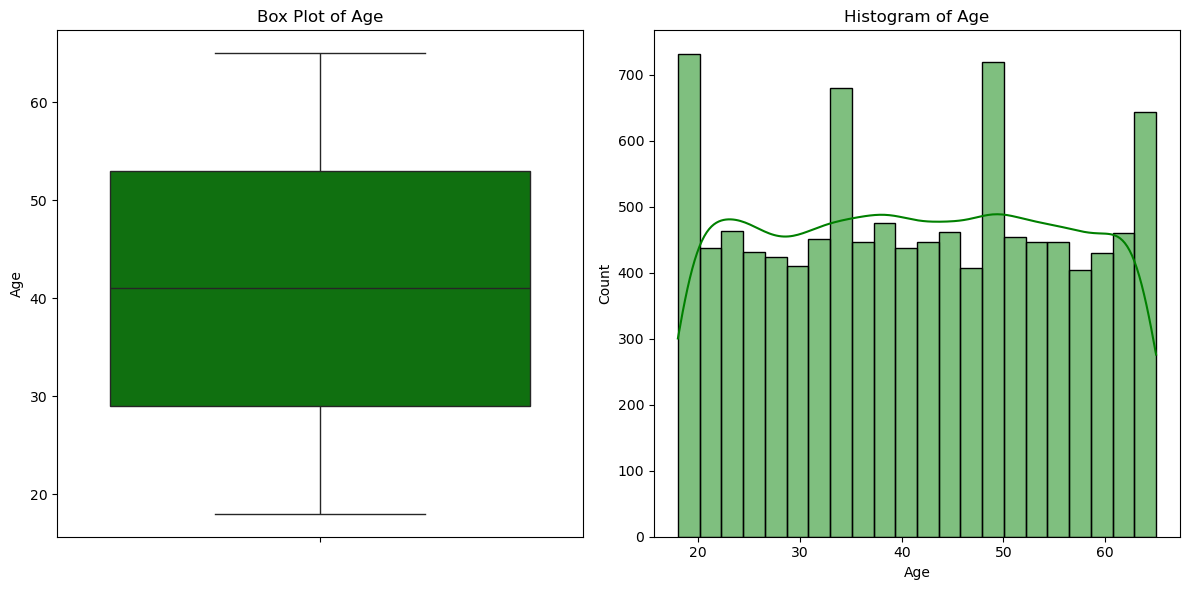

In [9]:
# Visualizations
# Histogram and Boxplot for numerical variable (Age)
feature = "Age"
plt.figure(figsize=(12, 6))

# Box Plot
plt.subplot(1, 2, 1)
sns.boxplot(y=df[feature], color="green")
plt.title('Box Plot of Age')

# Histogram with KDE
plt.subplot(1, 2, 2)
sns.histplot(data=df, x=feature, kde=True, color="green")
plt.title('Histogram of Age')
plt.tight_layout()
plt.show()

C:\Users\Moko_\AppData\Local\Temp\ipykernel_33444\3612807590.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="Greens", ax=ax)
C:\Users\Moko_\AppData\Local\Temp\ipykernel_33444\3612807590.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="Greens", ax=ax)
C:\Users\Moko_\AppData\Local\Temp\ipykernel_33444\3612807590.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, palette="Greens", ax=ax)
C:\Users\Moko_\AppData\Local\Temp\ipykernel_33444\3612807590.py:

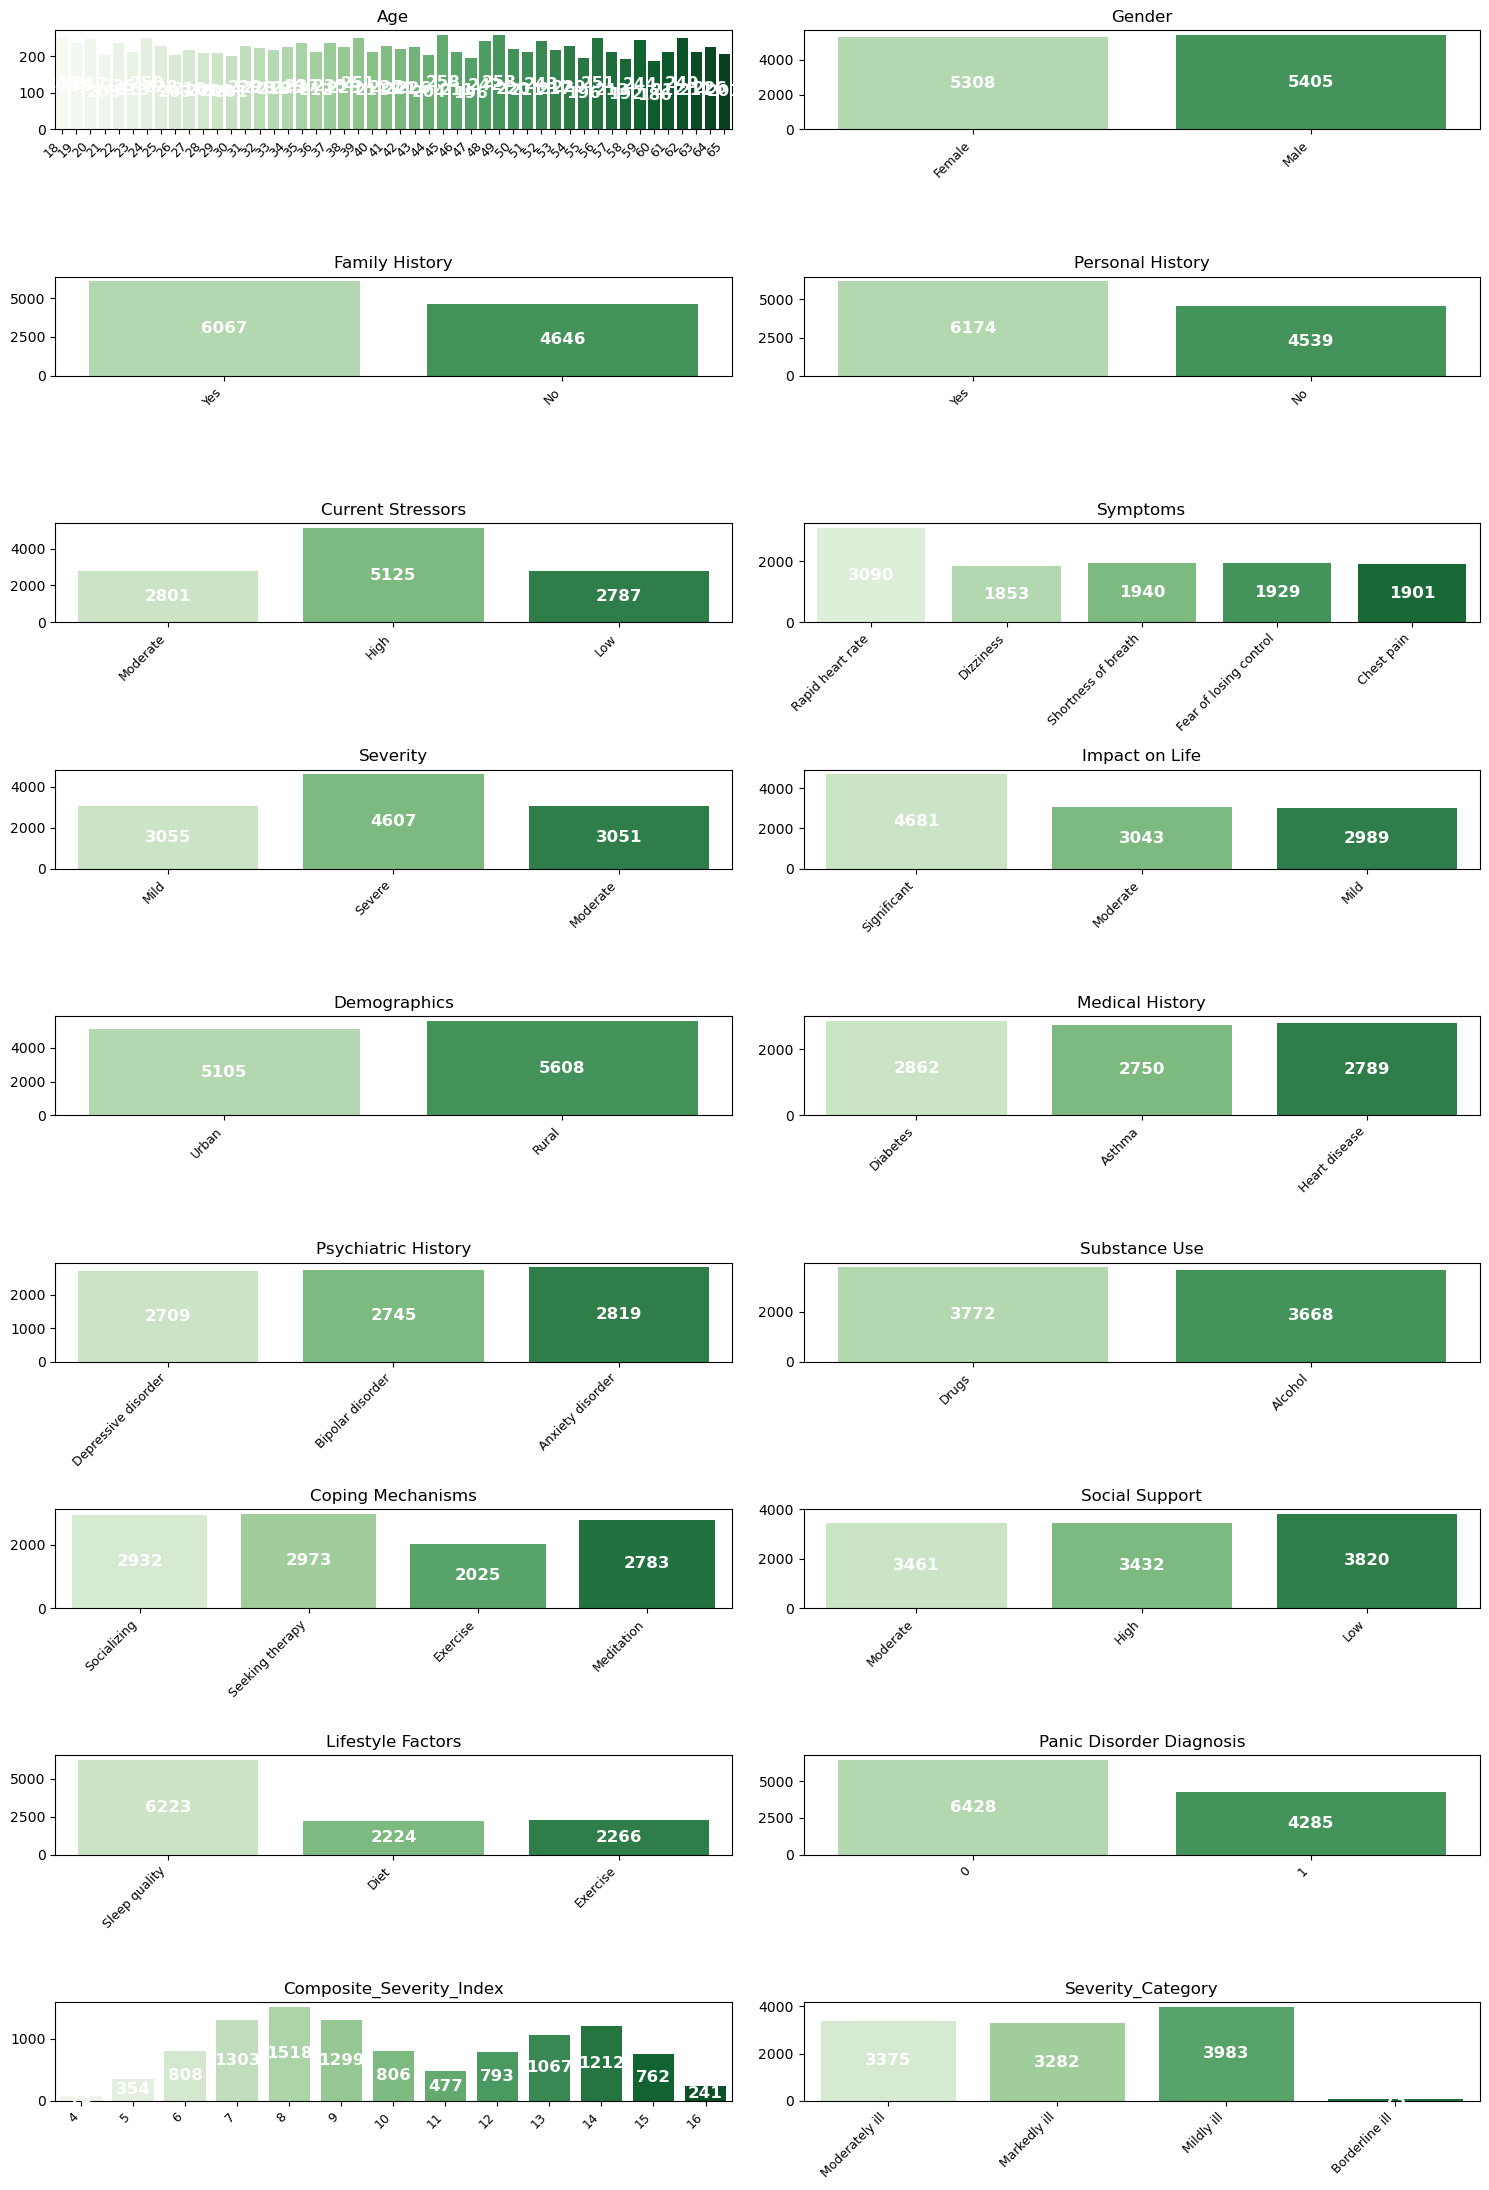

In [10]:
# Bar Plots of ALL Categorical Features (except ID, Age, Panic Disorder Diagnosis)
selected_columns = [
    col for col in df.columns
    if col not in ["Participant ID"]
]

plt.figure(figsize=(15, 22))

for i, feature in enumerate(selected_columns):
    ax = plt.subplot(9, 2, i+1)
    sns.countplot(data=df, x=feature, palette="Greens", ax=ax)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.xlabel('')
    plt.ylabel('')
    plt.title(feature, fontsize=12)

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='center', fontsize=12, color='white', weight='bold')

plt.tight_layout()
plt.show()

## ***3. Data Preprocessing***

In [11]:
# Handling Missing Values
# Check for missing values in the dataset
print("Missing values in dataset:")
print(df.isnull().sum())

Missing values in dataset:
Participant ID                 0
Age                            0
Gender                         0
Family History                 0
Personal History               0
Current Stressors              0
Symptoms                       0
Severity                       0
Impact on Life                 0
Demographics                   0
Medical History             2312
Psychiatric History         2440
Substance Use               3273
Coping Mechanisms              0
Social Support                 0
Lifestyle Factors              0
Panic Disorder Diagnosis       0
Composite_Severity_Index       0
Severity_Category              0
dtype: int64


> `NOTE:` Since there are no missing values, handling of missing values will be skipped

In [12]:
# ==================== 2. Feature Engineering & Pre-Encoding ====================

# 1) Drop Participant ID
if 'Participant ID' in df.columns:
    df.drop(columns=['Participant ID'], inplace=True)
    print("Dropped 'Participant ID'.")

# 2) Define placeholder/variable names
DIAGNOSIS_COL = "Panic Disorder Diagnosis"
PAO_LABEL_COL = "Panic Attack Occurrence"
PAO_PROBA_COL = "Panic Attack Occurrence Probability"

PAS_PROBA_COL = "Panic Attack Severity Probability"

#Feature Engineered Column
PAS_LABEL_COL = "Panic Attack Severity" # This is the only feature engineered column as we will map the "Severity_Category" to make this the target variable for predicting panic attack severity

# 3) Create placeholder columns
for col in [PAO_LABEL_COL, PAO_PROBA_COL, PAS_PROBA_COL]:
    if col not in df.columns:
        df[col] = pd.Series([pd.NA] * len(df), dtype="Float64")

# Special handling for the Int64 target
if PAS_LABEL_COL not in df.columns:
    df[PAS_LABEL_COL] = pd.Series([pd.NA] * len(df), dtype="Int64")

print(f"Created placeholder columns: {PAO_LABEL_COL}, {PAS_LABEL_COL}, etc.")

# 4) Create the Target Variable 'Panic Attack Severity'
print(f"Populating target variable: '{PAS_LABEL_COL}'")
severity_mapping = {
    'Borderline ill': 1,  # Mild
    'Mildly ill': 1,      # Mild
    'Moderately ill': 2,  # Moderate
    'Markedly ill': 3      # Severe
}
df[PAS_LABEL_COL] = df['Severity_Category'].map(severity_mapping)
print(f"Mapped severity strings to '{PAS_LABEL_COL}'.")
print(df[PAS_LABEL_COL].value_counts(dropna=False).sort_index())

Dropped 'Participant ID'.
Created placeholder columns: Panic Attack Occurrence, Panic Attack Severity, etc.
Populating target variable: 'Panic Attack Severity'
Mapped severity strings to 'Panic Attack Severity'.
Panic Attack Severity
1    4056
2    3375
3    3282
Name: count, dtype: int64


In [13]:
# ==================== 3. Create Train/Test Split ====================
print("\nCreating train/test split...")

# We will stratify on the *new target variable* for balanced splits
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[PAS_LABEL_COL]  # Stratify on our new 1, 2, 3 target
)

print(f"Created train_df with shape: {train_df.shape}")
print(f"Created test_df with shape: {test_df.shape}")

print("\n--- Train/Test Split Verification (Target Distribution) ---")
print("\nTraining Set:")
print(train_df[PAS_LABEL_COL].value_counts(normalize=True).sort_index())
print("\nTest Set:")
print(test_df[PAS_LABEL_COL].value_counts(normalize=True).sort_index())


Creating train/test split...
Created train_df with shape: (8570, 22)
Created test_df with shape: (2143, 22)

--- Train/Test Split Verification (Target Distribution) ---

Training Set:
Panic Attack Severity
1    0.378646
2    0.315053
3    0.306301
Name: proportion, dtype: float64

Test Set:
Panic Attack Severity
1    0.378441
2    0.314979
3    0.306580
Name: proportion, dtype: float64


### Check class imbalance of target variables

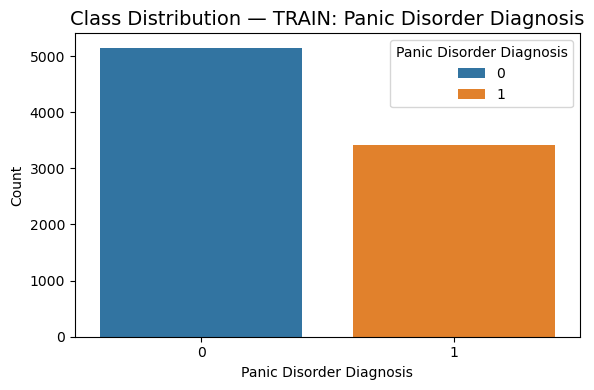

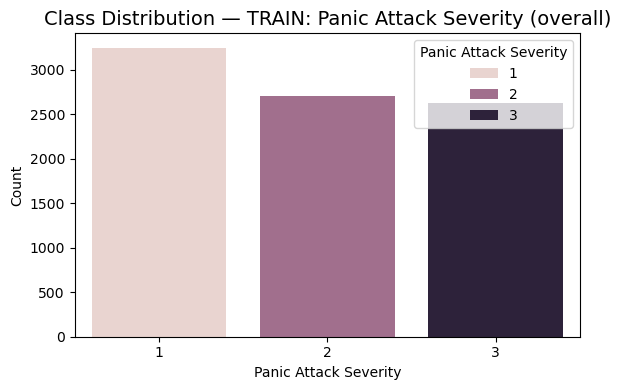

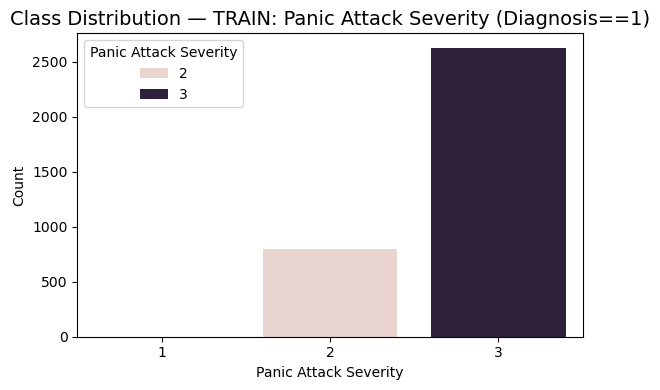

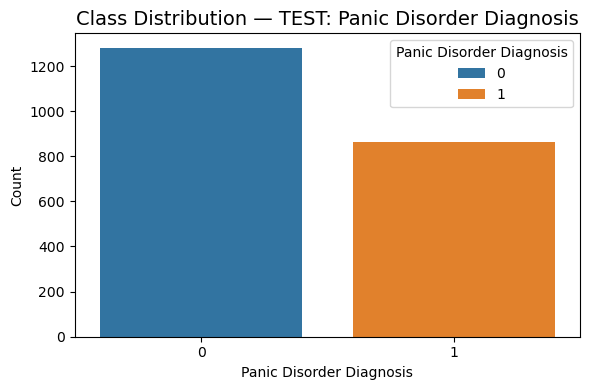

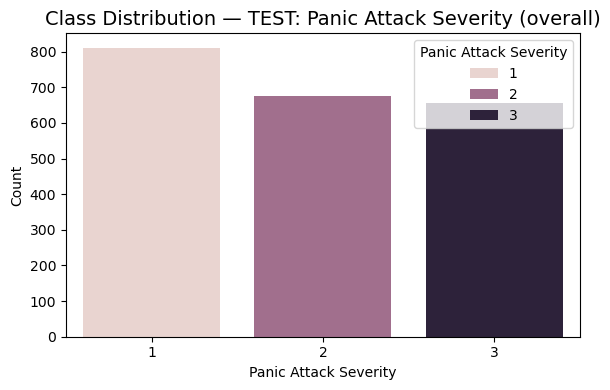

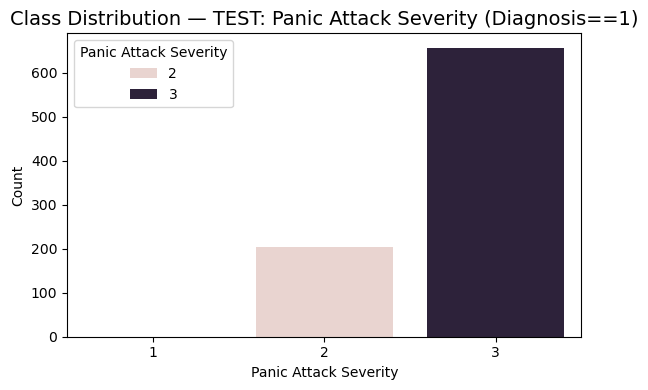

In [14]:
# =========================
# Visualizations (targets) - CORRECTED
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# NOTE: This cell assumes the previous cells have been run, so
# 'train_df', 'test_df', 'DIAGNOSIS_COL', and 'PAS_LABEL_COL' already exist.

def plot_count(df, col, title, order=None):
    """
    Plotting function, fixed to use plt.show() and remove errors.
    """
    plt.figure(figsize=(6, 4))
    if order is None:
        order = sorted(pd.unique(df[col].dropna()))

    sns.countplot(
        data=df,
        x=col,
        hue=col,
        order=order,
        hue_order=order,
        # legend=False  <-- This argument is invalid and has been removed.
    )
    plt.title(title, fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(ticks=range(len(order)), labels=[str(v) for v in order], rotation=0)
    plt.tight_layout()
    plt.show() # FIX: Display the plot instead of saving

# ---- TRAIN ----
# Panic Disorder Diagnosis (0/1)
plot_count(
    train_df,
    col=DIAGNOSIS_COL,
    title="Class Distribution — TRAIN: Panic Disorder Diagnosis",
    order=[0, 1]
)

# Panic Attack Severity overall (mapped to {1,2,3})
plot_count(
    train_df,
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TRAIN: {PAS_LABEL_COL} (overall)",
    order=[1, 2, 3] # Order is {1, 2, 3}
)

# Panic Attack Severity for diagnosed==1 only (binary {2,3})
plot_count(
    train_df.loc[train_df[DIAGNOSIS_COL] == 1],
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TRAIN: {PAS_LABEL_COL} (Diagnosis==1)",
    order=[1, 2, 3] # Correct, as '1' (Mild) does not exist here
)

# ---- TEST ----
plot_count(
    test_df,
    col=DIAGNOSIS_COL,
    title="Class Distribution — TEST: Panic Disorder Diagnosis",
    order=[0, 1]
)

plot_count(
    test_df,
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TEST: {PAS_LABEL_COL} (overall)",
    order=[1, 2, 3] # Order is {1, 2, 3}
)

plot_count(
    test_df.loc[test_df[DIAGNOSIS_COL] == 1],
    col=PAS_LABEL_COL, # FIX: Use your correct target variable
    title=f"Class Distribution — TEST: {PAS_LABEL_COL} (Diagnosis==1)",
    order=[1, 2, 3] # Correct
)

### Encoding & Class Normalization

In [15]:
# ==================== OCCURRENCE TASK: encode all non-target features ====================
# This code assumes 'train_df', 'test_df', and the placeholder column names
# (e.g., PAS_LABEL_COL, PAO_LABEL_COL) are already in memory from previous cells.
#
# We will create X_train_occ_enc and X_test_occ_enc for the "Occurrence" model.

# Targets (binary for occurrence)
y_train_occ = train_df['Panic Disorder Diagnosis'].astype(int)
y_test_occ  = test_df['Panic Disorder Diagnosis'].astype(int)

# This is the FIXED (non-leaking) code
EXCLUDE_OCC = {
    'Panic Disorder Diagnosis',     # occurrence target

    # Placeholder/Output Columns (not features)
    PAO_LABEL_COL, PAO_PROBA_COL,
    PAS_LABEL_COL, PAS_PROBA_COL,

    # Leaky/Redundant Features (from your original list)
    'Severity',
    'Impact on Life',
    'Severity_num',
    'Impact on Life_num',
    'Symptoms',

    # --- ADDED AS REQUESTED ---
    'Composite_Severity_Index',
    'Severity_Category'
}

# Use the train columns as the canonical feature set; align test to it
FEATURE_COLS = [c for c in train_df.columns if c not in EXCLUDE_OCC]

X_train_occ = train_df[FEATURE_COLS].copy()
X_test_occ  = test_df.reindex(columns=FEATURE_COLS).copy()  # ensures same columns/order

# Infer types: numeric vs categorical
num_cols_occ = list(X_train_occ.select_dtypes(include=['number']).columns)
cat_cols_occ = [c for c in FEATURE_COLS if c not in num_cols_occ]

# Version-safe OneHotEncoder
def _make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# No imputation (keep data unmodified); Age has no missings, pass through
numeric_pipe = "passthrough"
categorical_pipe = _make_ohe()

# ColumnTransformer
transformers = []
if num_cols_occ:
    transformers.append(("num", numeric_pipe, num_cols_occ))
if cat_cols_occ:
    transformers.append(("cat", categorical_pipe, cat_cols_occ))

if not transformers:
    raise ValueError("[OCC] No valid feature columns found. Check exclusions and dataset columns.")

pre_occ = ColumnTransformer(transformers, remainder="drop")

# ==== FIT ONLY ON TRAIN; TRANSFORM BOTH ====
X_train_occ_enc = pre_occ.fit_transform(X_train_occ)
X_test_occ_enc  = pre_occ.transform(X_test_occ)

# --- Print Summary ---
print("[OCC] excluded (targets/outputs):", sorted(EXCLUDE_OCC & set(train_df.columns)))
print("[OCC] numeric columns:", num_cols_occ if num_cols_occ else "None")
print("[OCC] categorical columns:", cat_cols_occ if cat_cols_occ else "None")
print("[OCC] shapes → train:", X_train_occ_enc.shape, " test:", X_test_occ_enc.shape)
print("[OCC] y_train base rate:", float(y_train_occ.mean()))

# Retrieve the feature names from the ColumnTransformer
try:
    feature_names = pre_occ.get_feature_names_out()

    # Convert the encoded numpy arrays into DataFrames
    train_encoded_df = pd.DataFrame(X_train_occ_enc, columns=feature_names)
    test_encoded_df  = pd.DataFrame(X_test_occ_enc,  columns=feature_names)

    # Optionally, add back the target column(s) for reference
    train_encoded_df['Panic_Disorder_Diagnosis'] = y_train_occ.values
    test_encoded_df['Panic_Disorder_Diagnosis']  = y_test_occ.values

    # Save to CSV
    train_encoded_df.to_csv("train_onehot_occ.csv", index=False)
    test_encoded_df.to_csv("test_onehot_occ.csv", index=False)

    print("\n✅ Encoded CSVs saved as train_onehot_occ.csv and test_onehot_occ.csv")

except Exception as e:
    print(f"\nCould not get feature names or save CSVs. Error: {e}")
    print("The encoded arrays 'X_train_occ_enc' and 'X_test_occ_enc' are still ready for modeling.")

[OCC] excluded (targets/outputs): ['Composite_Severity_Index', 'Impact on Life', 'Panic Attack Occurrence', 'Panic Attack Occurrence Probability', 'Panic Attack Severity', 'Panic Attack Severity Probability', 'Panic Disorder Diagnosis', 'Severity', 'Severity_Category', 'Symptoms']
[OCC] numeric columns: ['Age']
[OCC] categorical columns: ['Gender', 'Family History', 'Personal History', 'Current Stressors', 'Demographics', 'Medical History', 'Psychiatric History', 'Substance Use', 'Coping Mechanisms', 'Social Support', 'Lifestyle Factors']
[OCC] shapes → train: (8570, 33)  test: (2143, 33)
[OCC] y_train base rate: 0.39941656942823806

✅ Encoded CSVs saved as train_onehot_occ.csv and test_onehot_occ.csv


## ***4. Model Training***

### ------***Random Forest (RF) - Occurrence Model***------

In [16]:
# import time
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import (
#     accuracy_score, precision_score, recall_score, f1_score, 
#     roc_auc_score, log_loss, confusion_matrix, ConfusionMatrixDisplay, roc_curve
# )
# from sklearn.model_selection import cross_validate, cross_val_predict, train_test_split

# # ============================================================
# # 1. Model Training (Occurrence RF - Baseline)
# # ============================================================

# # --- Model Definition ---
# rf_occ = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=None,      # Unconstrained (leads to 1.0 Train score)
#     max_features=None,
#     min_samples_leaf=1,
#     min_samples_split=2,
#     random_state=43,
#     n_jobs=-1
# )

# print("Training Random Forest Occurrence Model (with 10-Fold CV)...")
# start_time = time.time()

# # --- Step A: 10-Fold Cross-Validation (Validation Column) ---
# scoring_metrics = {
#     'accuracy': 'accuracy',
#     'precision': 'precision',
#     'recall': 'recall',
#     'f1': 'f1',
#     'roc_auc': 'roc_auc'
# }

# cv_results = cross_validate(
#     estimator=rf_occ,
#     X=X_train_occ_enc,
#     y=y_train_occ,
#     cv=10,
#     scoring=scoring_metrics,
#     n_jobs=-1
# )

# # --- Step B: Final Fit (Train Column) ---
# rf_occ.fit(X_train_occ_enc, y_train_occ)

# train_time_rf_occ = time.time() - start_time

# # --- Step C: Calculate "Full Fit" Metrics (For the 'Train' Column) ---
# # This quantifies the Memorization (usually near 1.0)
# y_pred_train_full = rf_occ.predict(X_train_occ_enc)
# proba_train_full  = rf_occ.predict_proba(X_train_occ_enc)

# tr_acc  = accuracy_score(y_train_occ, y_pred_train_full)
# tr_prec = precision_score(y_train_occ, y_pred_train_full)
# tr_rec  = recall_score(y_train_occ, y_pred_train_full)
# tr_f1   = f1_score(y_train_occ, y_pred_train_full)
# tr_auc  = roc_auc_score(y_train_occ, proba_train_full[:, 1])


# # ============================================================
# # 2. Test Set Evaluation (Test Column)
# # ============================================================

# start_eval_time = time.time()
# y_pred_test_occ = rf_occ.predict(X_test_occ_enc)
# proba_test_occ  = rf_occ.predict_proba(X_test_occ_enc) 
# eval_time_rf_occ = time.time() - start_eval_time

# # Calculate Test Metrics
# te_acc  = accuracy_score(y_test_occ, y_pred_test_occ)
# te_prec = precision_score(y_test_occ, y_pred_test_occ, zero_division=0)
# te_rec  = recall_score(y_test_occ, y_pred_test_occ, zero_division=0)
# te_f1   = f1_score(y_test_occ, y_pred_test_occ, zero_division=0)
# te_auc  = roc_auc_score(y_test_occ, proba_test_occ[:, 1])

# # ============================================================
# # 3. PRINT COMPARISON TABLE (The "Gold Standard" Format)
# # ============================================================

# print("\n" + "="*85)
# print(f"{'METRIC':<15} | {'TRAIN (Full Fit)':<18} | {'VALIDATION (10-Fold)':<20} | {'TEST (Hold-out)':<18}")
# print("-" * 85)
# print(f"{'Accuracy':<15} | {tr_acc:<18.4f} | {cv_results['test_accuracy'].mean():<20.4f} | {te_acc:<18.4f}")
# print(f"{'Precision':<15} | {tr_prec:<18.4f} | {cv_results['test_precision'].mean():<20.4f} | {te_prec:<18.4f}")
# print(f"{'Recall':<15} | {tr_rec:<18.4f} | {cv_results['test_recall'].mean():<20.4f} | {te_rec:<18.4f}")
# print(f"{'F1 Score':<15} | {tr_f1:<18.4f} | {cv_results['test_f1'].mean():<20.4f} | {te_f1:<18.4f}")
# print(f"{'ROC AUC':<15} | {tr_auc:<18.4f} | {cv_results['test_roc_auc'].mean():<20.4f} | {te_auc:<18.4f}")
# print("=" * 85)
# print(f"Total Training Time: {train_time_rf_occ:.2f}s")
# print(f"Total Testing Time:  {eval_time_rf_occ:.2f}s")


# # ============================================================
# # 4. Confusion Matrices (Train vs Validation vs Test)
# # ============================================================
# # We use 3 columns now to show the full progression
# fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5)) 

# # --- Matrix 1: TRAIN (Memorization / Full Fit) ---
# # This uses the predictions from the model fitted on ALL training data.
# # Expect near-perfect results (0 errors) due to Overfitting.
# cm_train = confusion_matrix(y_train_occ, y_pred_train_full, labels=[0, 1])
# disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1])
# disp_train.plot(ax=axes_cm[0], values_format='d', colorbar=False, cmap='Oranges')
# axes_cm[0].set_title(f"Occurrence (RF) — TRAIN (Full Fit)\n(Acc: {tr_acc:.4f})")

# # --- Matrix 2: VALIDATION (Honest / Cross-Validation) ---
# # We use cross_val_predict to show the errors the model makes during CV.
# # This reveals the true "Generalization" ability during training.
# print("\nGenerating CV Predictions for Matrix...")
# y_pred_cv = cross_val_predict(rf_occ, X_train_occ_enc, y_train_occ, cv=10, n_jobs=-1)

# cm_cv = confusion_matrix(y_train_occ, y_pred_cv, labels=[0, 1])
# disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=[0, 1])
# disp_cv.plot(ax=axes_cm[1], values_format='d', colorbar=False, cmap='Greens')
# axes_cm[1].set_title(f"Occurrence (RF) — VALIDATION (CV)\n(Acc: {cv_results['test_accuracy'].mean():.4f})")

# # --- Matrix 3: TEST (Real World / Hold-Out) ---
# # The final exam.
# cm_test = confusion_matrix(y_test_occ, y_pred_test_occ, labels=[0, 1])
# disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0, 1])
# disp_test.plot(ax=axes_cm[2], values_format='d', colorbar=False, cmap='Blues')
# axes_cm[2].set_title(f"Occurrence (RF) — TEST SET\n(Acc: {te_acc:.4f})")

# plt.tight_layout()
# plt.show()


# # ============================================================
# # 5. Learning Curves (Train vs Validation; ROC = Train vs Test)
# # ============================================================

# train_fracs = np.linspace(0.1, 1.0, 10)
# train_losses = []
# val_losses   = []
# train_f1s    = []
# val_f1s      = []
# train_recalls = []
# val_recalls   = []

# print("\n[RF OCC] Generating learning curve data (Train vs Validation)...")

# # Robust handling whether y_train_occ is array or Series
# y_train_series = (
#     y_train_occ if hasattr(y_train_occ, "iloc")
#     else pd.Series(y_train_occ)
# )

# for frac in train_fracs:
#     n = max(1, int(len(X_train_occ_enc) * frac))
#     X_sub_orig = X_train_occ_enc[:n]
#     y_sub_orig = y_train_series.iloc[:n]

#     # --- Train/Validation split on this subset (stratified) ---
#     X_tr_sub, X_val_sub, y_tr_sub, y_val_sub = train_test_split(
#         X_sub_orig,
#         y_sub_orig,
#         test_size=0.2,
#         stratify=y_sub_orig,
#         random_state=42
#     )

#     # Clone model (same params as rf_occ)
#     rf_sub = RandomForestClassifier(
#         n_estimators=100,
#         max_depth=None,
#         max_features=None,
#         min_samples_leaf=1,
#         min_samples_split=2,
#         random_state=43,
#         n_jobs=-1
#     )
#     rf_sub.fit(X_tr_sub, y_tr_sub)

#     # Predictions on TRAIN subset and VALIDATION subset
#     proba_tr  = rf_sub.predict_proba(X_tr_sub)
#     pred_tr   = rf_sub.predict(X_tr_sub)

#     proba_val = rf_sub.predict_proba(X_val_sub)
#     pred_val  = rf_sub.predict(X_val_sub)

#     # Store metrics: TRAIN vs VALIDATION
#     train_losses.append(log_loss(y_tr_sub, proba_tr))
#     val_losses.append(log_loss(y_val_sub, proba_val))

#     train_f1s.append(f1_score(y_tr_sub, pred_tr, zero_division=0))
#     val_f1s.append(f1_score(y_val_sub, pred_val, zero_division=0))

#     train_recalls.append(recall_score(y_tr_sub, pred_tr, zero_division=0))
#     val_recalls.append(recall_score(y_val_sub, pred_val, zero_division=0))

# # --- Plotting ---
# x_vals = train_fracs * 100
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# # 3. Log Loss (Train vs Validation)
# axes[0, 0].plot(x_vals, train_losses, 'o-', label='Train')
# axes[0, 0].plot(x_vals, val_losses, 'o-', label='Validation')
# axes[0, 0].set_title("Log Loss vs Training Size")
# axes[0, 0].set_xlabel("% Training Data")
# axes[0, 0].set_ylabel("Log Loss")
# axes[0, 0].legend()
# axes[0, 0].grid(True, alpha=0.3)

# # 1. F1 Score (Train vs Validation)
# axes[0, 1].plot(x_vals, train_f1s, 'o-', label='Train')
# axes[0, 1].plot(x_vals, val_f1s, 'o-', label='Validation')
# axes[0, 1].set_title("F1 Score vs Training Size")
# axes[0, 1].set_xlabel("% Training Data")
# axes[0, 1].set_ylabel("F1 Score")
# axes[0, 1].legend()
# axes[0, 1].grid(True, alpha=0.3)

# # 2. Recall (Train vs Validation)
# axes[1, 0].plot(x_vals, train_recalls, 'o-', label='Train')
# axes[1, 0].plot(x_vals, val_recalls, 'o-', label='Validation')
# axes[1, 0].set_title("Recall vs Training Size")
# axes[1, 0].set_xlabel("% Training Data")
# axes[1, 0].set_ylabel("Recall")
# axes[1, 0].legend()
# axes[1, 0].grid(True, alpha=0.3)

# # 4. ROC Curve (Train vs Test using full model)
# fpr_tr, tpr_tr, _ = roc_curve(y_train_occ, proba_train_full[:, 1])
# fpr_te, tpr_te, _ = roc_curve(y_test_occ, proba_test_occ[:, 1])

# axes[1, 1].plot(fpr_tr, tpr_tr, label=f'Train AUC = {tr_auc:.4f}')
# axes[1, 1].plot(fpr_te, tpr_te, label=f'Test AUC = {te_auc:.4f}')
# axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
# axes[1, 1].set_title("ROC Curve (Train vs Test)")
# axes[1, 1].set_xlabel("False Positive Rate")
# axes[1, 1].set_ylabel("True Positive Rate")
# axes[1, 1].legend()
# axes[1, 1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# RF OCC TUNING


1. Starting Randomized Search Hyperparameter Tuning...
Fitting 10 folds for each of 30 candidates, totalling 300 fits
Total Tuning Time: 82.22 seconds

[RF OCC][TUNING] Per-run CV table (sorted by F1 rank):
 run  rank_f1  n_estimators  max_depth  min_samples_leaf  min_samples_split max_features accuracy precision recall     f1 roc_auc test_log_loss mean_fit_time
  16        1           800         10                 1                 10          0.5   0.9151    0.8414 0.9711 0.9014  0.9670        0.1941          5.64
  17        2           500         20                 2                 20          0.5   0.9140    0.8436 0.9644 0.8997  0.9665        0.1975          3.87
   5        3           500         20                 1                 20         sqrt   0.9139    0.8448 0.9620 0.8993  0.9672        0.2179          2.68
  29        4           500         10                 8                  5          0.5   0.9131    0.8386 0.9699 0.8992  0.9661        0.1997          3.15
  

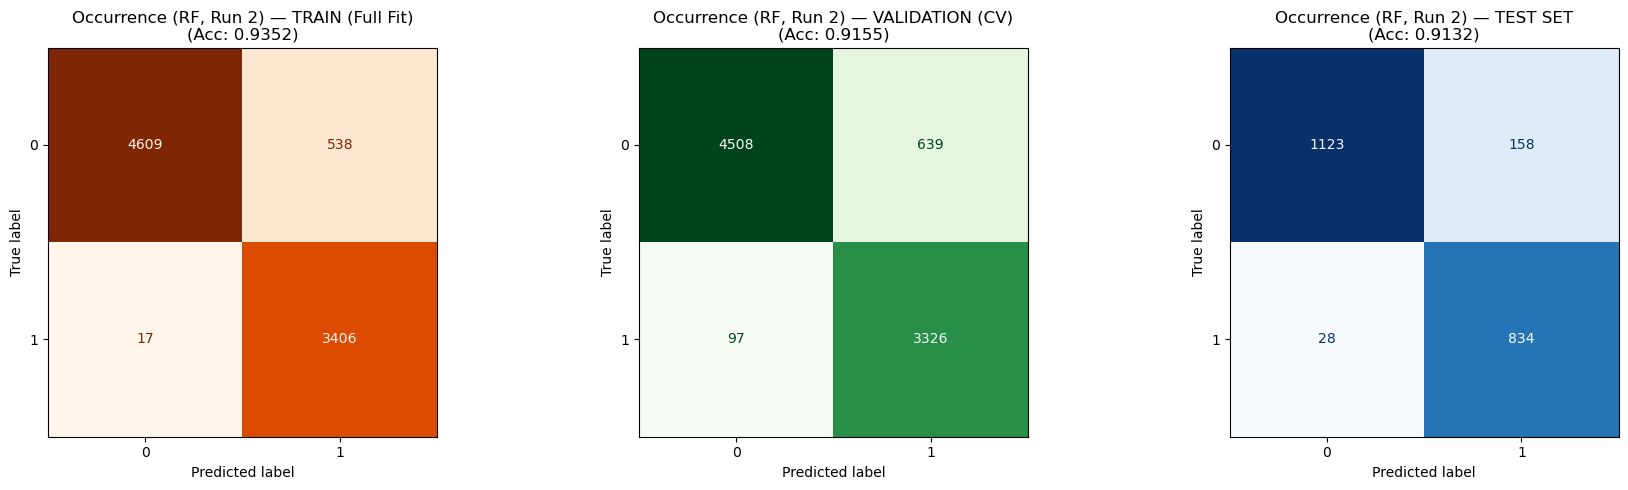


[RF OCC][BEST RUN 2] Generating learning curves (Train vs Validation)...


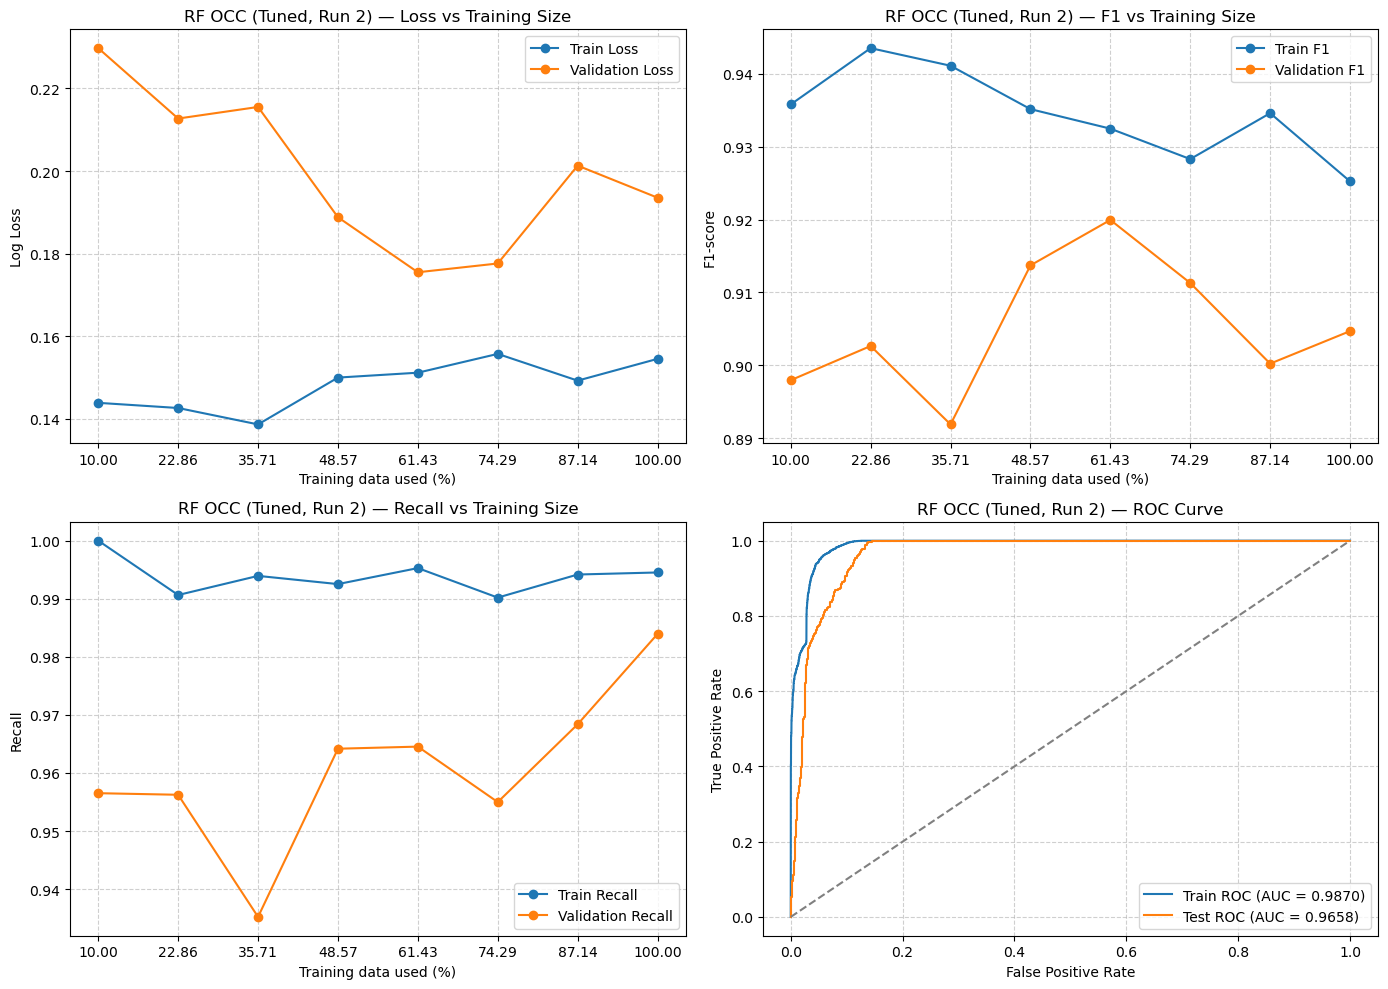

In [17]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Required for the new cross-validation logic
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate,
    cross_val_predict,
    train_test_split,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, log_loss, confusion_matrix, ConfusionMatrixDisplay,
    # ADDED: Required for final comparison table
    accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve
)

# ======================== Occurrence Model - With hyperparameter tuning ========================

# --- 1. Tune the models (RandomizedSearchCV) ---

# 10-fold CV (used both for tuning and final validation)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=43)

# Hyperparameter distributions (Randomized Search)
param_distributions = {
    "n_estimators": [50, 100, 200, 300, 500, 800],
    "max_depth": [10, 15, 20],
    "min_samples_leaf": [1, 2, 5, 8, 10, 12],
    "min_samples_split": [2, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5]
}

base_rf = RandomForestClassifier(
    random_state=43,
    n_jobs=-1
)

# Multi-metric scoring for each random search run
scoring = {
    "f1": "f1",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "log_loss": "neg_log_loss",
}

print("\n========================================================")
print("1. Starting Randomized Search Hyperparameter Tuning...")
print("========================================================")

# Run tuning
random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_distributions,
    n_iter=30, # Number of parameter settings that are sampled
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    refit="f1", # <<< refit on best F1
    verbose=1,
    random_state=43,
    return_train_score=True
)

t0 = time.time()
random_search.fit(X_train_occ_enc, y_train_occ)
tuning_time = time.time() - t0
print(f"Total Tuning Time: {tuning_time:.2f} seconds")


# --- 2. Rank them based on f1 (unchanged from original code) ---
cv_results_tuning = random_search.cv_results_
df = pd.DataFrame(cv_results_tuning)

# Flip sign of log_loss
df["mean_test_log_loss_pos"] = -df["mean_test_log_loss"]

# Keep only the columns we care about
cols = [
    "rank_test_f1", # <<< rank by f1
    "param_n_estimators", "param_max_depth", "param_min_samples_leaf",
    "param_min_samples_split", "param_max_features",
    "mean_test_accuracy", "mean_test_precision", "mean_test_recall",
    "mean_test_f1", "mean_test_roc_auc", "mean_test_log_loss_pos", "mean_fit_time"
]

results_table = df[cols].copy()

# Make it a bit prettier: rename columns
results_table.columns = [
    "rank_f1", "n_estimators", "max_depth", "min_samples_leaf",
    "min_samples_split", "max_features", "accuracy", "precision",
    "recall", "f1", "roc_auc", "test_log_loss", "mean_fit_time"
]

# Add run index (1..n)
results_table.insert(0, "run", np.arange(1, len(results_table) + 1))

# Sort by best f1 (rank 1 = best)
results_table = results_table.sort_values("rank_f1")

print("\n[RF OCC][TUNING] Per-run CV table (sorted by F1 rank):")
# Format floats to 4 decimal places
results_table_display = results_table.copy()
float_cols = results_table_display.select_dtypes(include=[np.float64]).columns
for col in float_cols:
    if col != 'mean_fit_time':
        results_table_display[col] = results_table_display[col].apply(lambda x: f"{x:.4f}")
results_table_display['mean_fit_time'] = results_table_display['mean_fit_time'].apply(lambda x: f"{x:.2f}")

print(results_table_display.to_string(index=False))


# --- 3. Output the best params ---
best_params = random_search.best_params_
print("\n[RF OCC][TUNING] Best parameters found by RandomizedSearchCV:")
print(best_params)
print(f"[RF OCC][TUNING] Best mean CV F1: {random_search.best_score_:.4f}")


# ======================== 4. Run the Best Model 3 Times with 10-Fold CV ========================

print("\n========================================================")
print("4. Final Validation: Running tuned model 3 times (10-fold CV)...")
print("========================================================")

RUNS = 3
all_runs_metrics = []
best_cv_f1_score = -1
best_run_cv_metrics = {}
# ADDED: Variable to store the *full* cross_validate results for the best run
best_run_cv_results = None

for i in range(1, RUNS + 1):
    # Use a different random_state for each run to ensure different results
    current_random_state = 100 + i

    # 1) Build a *fresh* RF with the best hyperparameters and new random state
    rf_run = RandomForestClassifier(
        **best_params,
        random_state=current_random_state,
        n_jobs=-1
    )

    print(f"--> Starting Run {i}...")

    # 2) Perform 10-fold Cross-Validation on the training data
    t_start_cv = time.time()
    cv_results = cross_validate(
        estimator=rf_run,
        X=X_train_occ_enc,
        y=y_train_occ,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        return_train_score=False, # Only need test metrics from CV folds
    )
    cv_total_time = time.time() - t_start_cv

    # Calculate mean metrics across 10 folds
    mean_f1 = np.mean(cv_results['test_f1'])

    metrics = {
        "Run": i,
        "Accuracy": np.mean(cv_results['test_accuracy']),
        "Precision": np.mean(cv_results['test_precision']),
        "Recall": np.mean(cv_results['test_recall']),
        "F1-Score": mean_f1,
        "ROC-AUC": np.mean(cv_results['test_roc_auc']),
        "Train Time (s)": np.mean(cv_results['fit_time']), # Avg fit time per fold
        "Total CV Time (s)": cv_total_time,
        "random_state": current_random_state # Keep track of the random state for the best run
    }
    all_runs_metrics.append(metrics)

    # 5. Track the best run based on the average CV F1-Score
    if mean_f1 > best_cv_f1_score:
        best_cv_f1_score = mean_f1
        # Store full set of CV results/data for later analysis/plots
        best_run_cv_metrics = metrics
        best_run_model_params = rf_run.get_params()
        # ADDED: Store the full cv_results dictionary for the best run
        best_run_cv_results = cv_results


# Convert metrics to DataFrame for a nice table
metrics_df = pd.DataFrame(all_runs_metrics)

# Display the table for the 3 runs (CV Average Metrics)
print("\n[RF OCC] Mean 10-Fold CV Performance (3 Independent Runs):")
metrics_df_display = metrics_df.drop(columns=['random_state']).copy()
float_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for col in float_cols:
    metrics_df_display[col] = metrics_df_display[col].apply(lambda x: f"{x:.4f}")
time_cols = ['Train Time (s)', 'Total CV Time (s)']
for col in time_cols:
    metrics_df_display[col] = metrics_df_display[col].apply(lambda x: f"{x:.2f}")

print(metrics_df_display.to_string(index=False))

# Calculate and display the average metrics across the 3 runs
avg_metrics = metrics_df[float_cols + ['Train Time (s)', 'Total CV Time (s)']].mean()
print("\n[RF OCC] Average Metrics Across the 3 Runs:")

avg_table_data = {
    "Metric": avg_metrics.index,
    "Average Value": [f"{v:.4f}" if m in float_cols else f"{v:.2f}" for m, v in avg_metrics.items()]
}
avg_metrics_df = pd.DataFrame(avg_table_data)
print(avg_metrics_df.to_string(index=False))

# ======================== 5. Finalize and Plot Best Run Results ========================

if best_run_cv_metrics:
    best_run_index = best_run_cv_metrics["Run"]
    best_run_f1 = best_run_cv_metrics["F1-Score"]

    print(f"\n========================================================")
    print(f"5. Analyzing Best CV Run (Run {best_run_index}) with Avg CV F1: {best_run_f1:.4f}")
    print(f"========================================================")

    # 1. Train the best model on the FULL training set
    final_best_rf = RandomForestClassifier(**best_run_model_params)
    # The random state is critical for reproducibility
    final_best_rf.random_state = best_run_cv_metrics["random_state"]
    t_start_train = time.time()
    final_best_rf.fit(X_train_occ_enc, y_train_occ)
    final_train_time = time.time() - t_start_train

    # 2. Evaluate on BOTH the TRAIN and TEST sets

    # --- Predictions for TRAIN set (Full Fit) ---
    y_pred_train_full = final_best_rf.predict(X_train_occ_enc) # Renamed for clarity in CM plot
    proba_train_best = final_best_rf.predict_proba(X_train_occ_enc)

    # --- Predictions for TEST set ---
    t_start_eval = time.time()
    y_pred_best = final_best_rf.predict(X_test_occ_enc) # This is y_pred_test_occ in the original format
    proba_best = final_best_rf.predict_proba(X_test_occ_enc)
    final_eval_time = time.time() - t_start_eval

    # ============================================================
    # --- Final Train and Test Metrics Output ---
    # ============================================================

    # Calculate Train Set Metrics (Full Fit)
    tr_acc = accuracy_score(y_train_occ, y_pred_train_full)
    tr_prec = precision_score(y_train_occ, y_pred_train_full, zero_division=0)
    tr_rec = recall_score(y_train_occ, y_pred_train_full, zero_division=0)
    tr_f1 = f1_score(y_train_occ, y_pred_train_full, zero_division=0)
    tr_auc = roc_auc_score(y_train_occ, proba_train_best[:, 1])
    # train_logloss = log_loss(y_train_occ, proba_train_best) # Not in gold standard table

    # Calculate Test Set Metrics (Hold-out)
    te_acc = accuracy_score(y_test_occ, y_pred_best)
    te_prec = precision_score(y_test_occ, y_pred_best, zero_division=0)
    te_rec = recall_score(y_test_occ, y_pred_best, zero_division=0)
    te_f1 = f1_score(y_test_occ, y_pred_best, zero_division=0)
    te_auc = roc_auc_score(y_test_occ, proba_best[:, 1])
    # test_logloss = log_loss(y_test_occ, proba_best) # Not in gold standard table

    # Renaming variables for the Gold Standard format (Times)
    train_time_rf_occ = final_train_time
    eval_time_rf_occ = final_eval_time
    cv_results = best_run_cv_results # Use the full CV results from the best run

    # ============================================================
    # 3. PRINT COMPARISON TABLE (The "Gold Standard" Format)
    # ============================================================

    print("\n" + "="*85)
    print(f"{'METRIC':<15} | {'TRAIN (Full Fit)':<18} | {'VALIDATION (10-Fold)':<20} | {'TEST (Hold-out)':<18}")
    print("-" * 85)
    print(f"{'Accuracy':<15} | {tr_acc:<18.4f} | {cv_results['test_accuracy'].mean():<20.4f} | {te_acc:<18.4f}")
    print(f"{'Precision':<15} | {tr_prec:<18.4f} | {cv_results['test_precision'].mean():<20.4f} | {te_prec:<18.4f}")
    print(f"{'Recall':<15} | {tr_rec:<18.4f} | {cv_results['test_recall'].mean():<20.4f} | {te_rec:<18.4f}")
    print(f"{'F1 Score':<15} | {tr_f1:<18.4f} | {cv_results['test_f1'].mean():<20.4f} | {te_f1:<18.4f}")
    print(f"{'ROC AUC':<15} | {tr_auc:<18.4f} | {cv_results['test_roc_auc'].mean():<20.4f} | {te_auc:<18.4f}")
    print("=" * 85)
    print(f"Total Training Time: {train_time_rf_occ:.2f}s")
    print(f"Total Testing Time:  {eval_time_rf_occ:.2f}s")


    # ============================================================
    # 4. Confusion Matrices (Train vs Validation vs Test)
    # ============================================================
    # We use 3 columns now to show the full progression
    fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5)) 

    # --- Matrix 1: TRAIN (Memorization / Full Fit) ---
    # This uses the predictions from the model fitted on ALL training data.
    cm_train = confusion_matrix(y_train_occ, y_pred_train_full, labels=[0, 1])
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=[0, 1])
    disp_train.plot(ax=axes_cm[0], values_format='d', colorbar=False, cmap='Oranges')
    axes_cm[0].set_title(f"Occurrence (RF, Run {best_run_index}) — TRAIN (Full Fit)\n(Acc: {tr_acc:.4f})")

    clean_params = best_run_model_params.copy()
    current_random_state = clean_params.pop('random_state', None)

    # --- Matrix 2: VALIDATION (Honest / Cross-Validation) ---
    # We use cross_val_predict to show the errors the model makes during CV.
    print("\nGenerating CV Predictions for Matrix...")
    y_pred_cv = cross_val_predict(
        RandomForestClassifier(**clean_params, random_state=best_run_cv_metrics["random_state"]),
        X_train_occ_enc, 
        y_train_occ, 
        cv=10, 
        n_jobs=-1
    )

    cm_cv = confusion_matrix(y_train_occ, y_pred_cv, labels=[0, 1])
    disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=[0, 1])
    disp_cv.plot(ax=axes_cm[1], values_format='d', colorbar=False, cmap='Greens')
    axes_cm[1].set_title(f"Occurrence (RF, Run {best_run_index}) — VALIDATION (CV)\n(Acc: {cv_results['test_accuracy'].mean():.4f})")

    # --- Matrix 3: TEST (Real World / Hold-Out) ---
    # The final exam.
    cm_test = confusion_matrix(y_test_occ, y_pred_best, labels=[0, 1]) # y_pred_best is the test prediction
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=[0, 1])
    disp_test.plot(ax=axes_cm[2], values_format='d', colorbar=False, cmap='Blues')
    axes_cm[2].set_title(f"Occurrence (RF, Run {best_run_index}) — TEST SET\n(Acc: {te_acc:.4f})")

    plt.tight_layout()
    plt.show()

        # --- "vs. Training Size" plots (Learning Curves)
    #     -> Loss, F1, Recall: TRAIN vs VALIDATION
    #     -> ROC: TRAIN vs TEST (full data)
    train_fracs = np.linspace(0.1, 1.0, 8)
    train_losses = []
    val_losses = []
    train_f1s = []
    val_f1s = []
    train_recalls = []
    val_recalls = []

    print(f"\n[RF OCC][BEST RUN {best_run_index}] Generating learning curves (Train vs Validation)...")

    # Ensure y_train_occ is sliceable
    y_train_series = (
        y_train_occ if isinstance(y_train_occ, (pd.Series, pd.DataFrame))
        else pd.Series(y_train_occ)
    )

    for frac in train_fracs:
        # Use a subset of the training data
        n = max(1, int(len(X_train_occ_enc) * frac))
        X_sub_orig = X_train_occ_enc[:n]
        y_sub_orig = y_train_series.iloc[:n]

        # --- Train/Validation split on this subset (stratified) ---
        X_tr_sub, X_val_sub, y_tr_sub, y_val_sub = train_test_split(
            X_sub_orig,
            y_sub_orig,
            test_size=0.2,
            stratify=y_sub_orig,
            random_state=42
        )

        # New RF with SAME tuned parameters (reuse best hyperparams, fixed random_state)
        local_params = best_run_model_params.copy()
        # we control random_state explicitly
        local_params.pop("random_state", None)

        rf_sub = RandomForestClassifier(
            **local_params,
            random_state=final_best_rf.random_state,
        )
        rf_sub.fit(X_tr_sub, y_tr_sub)

        # --- Get predictions on TRAIN subset and VALIDATION subset ---
        proba_tr = rf_sub.predict_proba(X_tr_sub)
        y_pred_tr = rf_sub.predict(X_tr_sub)

        proba_val = rf_sub.predict_proba(X_val_sub)
        y_pred_val = rf_sub.predict(X_val_sub)

        # --- Calculate metrics: TRAIN vs VALIDATION ---
        train_losses.append(log_loss(y_tr_sub, proba_tr))
        val_losses.append(log_loss(y_val_sub, proba_val))

        train_f1s.append(f1_score(y_tr_sub, y_pred_tr, zero_division=0))
        val_f1s.append(f1_score(y_val_sub, y_pred_val, zero_division=0))

        train_recalls.append(recall_score(y_tr_sub, y_pred_tr, zero_division=0))
        val_recalls.append(recall_score(y_val_sub, y_pred_val, zero_division=0))

    # x-axis: % of training data used
    x_vals = train_fracs * 100

    # ROC curve data for Train and Test using the FINAL model
    fpr_rf_train, tpr_rf_train, _ = roc_curve(y_train_occ, proba_train_best[:, 1])
    fpr_rf, tpr_rf, _ = roc_curve(y_test_occ, proba_best[:, 1])

    # ============================
    # Combined 2x2 RF plots
    # ============================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 2x2 Grid


    # ---- 3) Loss vs Training Size (Train vs Validation) ----
    axes[0, 0].plot(x_vals, train_losses, marker='o', label='Train Loss')
    axes[0, 0].plot(x_vals, val_losses, marker='o', label='Validation Loss')
    axes[0, 0].set_xlabel("Training data used (%)")
    axes[0, 0].set_ylabel("Log Loss")
    axes[0, 0].set_title(f"RF OCC (Tuned, Run {best_run_index}) — Loss vs Training Size")
    axes[0, 0].legend()
    axes[0, 0].grid(True, linestyle='--', alpha=0.6)
    axes[0, 0].set_xticks(x_vals)

    # ---- 1) F1 vs Training Size (Train vs Validation) ----
    axes[0, 1].plot(x_vals, train_f1s, marker='o', label='Train F1')
    axes[0, 1].plot(x_vals, val_f1s, marker='o', label='Validation F1')
    axes[0, 1].set_xlabel("Training data used (%)")
    axes[0, 1].set_ylabel("F1-score")
    axes[0, 1].set_title(f"RF OCC (Tuned, Run {best_run_index}) — F1 vs Training Size")
    axes[0, 1].legend()
    axes[0, 1].grid(True, linestyle='--', alpha=0.6)
    axes[0, 1].set_xticks(x_vals)

    # ---- 2) Recall vs Training Size (Train vs Validation) ----
    axes[1, 0].plot(x_vals, train_recalls, marker='o', label='Train Recall')
    axes[1, 0].plot(x_vals, val_recalls, marker='o', label='Validation Recall')
    axes[1, 0].set_xlabel("Training data used (%)")
    axes[1, 0].set_ylabel("Recall")
    axes[1, 0].set_title(f"RF OCC (Tuned, Run {best_run_index}) — Recall vs Training Size")
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle='--', alpha=0.6)
    axes[1, 0].set_xticks(x_vals)

    # ---- 4) ROC Curve (Train vs Test, full data) ----
    axes[1, 1].plot(fpr_rf_train, tpr_rf_train, label=f'Train ROC (AUC = {tr_auc:.4f})')
    axes[1, 1].plot(fpr_rf, tpr_rf, label=f'Test ROC (AUC = {te_auc:.4f})')
    axes[1, 1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1, 1].set_title(f"RF OCC (Tuned, Run {best_run_index}) — ROC Curve")
    axes[1, 1].set_xlabel("False Positive Rate")
    axes[1, 1].set_ylabel("True Positive Rate")
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

else:
    print("\n[ERROR] No best run data was found to generate plots.")

In [18]:
import joblib
import os

# Define path
save_path = '../saved_models'
if not os.path.exists(save_path):
    os.makedirs(save_path)

print("SAVING DETECTION (OCCURRENCE) RESOURCES...")

# 1. Save the Detection Model (Currently named final_best_rf)
# NOTE: We rename it slightly in the save file to avoid confusion
joblib.dump(final_best_rf, os.path.join(save_path, 'detection_model.pkl'))
print(" - Model saved: detection_model.pkl")

# 2. Save the Detection Preprocessor
# In your code, this is named 'pre_occ' (The ColumnTransformer)
joblib.dump(pre_occ, os.path.join(save_path, 'detection_preprocessor.pkl'))
print(" - Preprocessor saved: detection_preprocessor.pkl")

print("✅ Detection resources secured.")

SAVING DETECTION (OCCURRENCE) RESOURCES...
 - Model saved: detection_model.pkl
 - Preprocessor saved: detection_preprocessor.pkl
✅ Detection resources secured.


### ------***Random Forest (RF) - Severity Model***------

In [19]:
# ============================================================
# Unified Random Forest Severity Model (Predicts 1, 2, 3) - Setup
# ============================================================

# --- 1. Prepare Full Training Data ---
# We use the FULL train_df (Diagnosis 0 AND 1).
EXCLUDE_SEV = {
    PAS_LABEL_COL,                  # Target
    DIAGNOSIS_COL,                  # Occurrence Target
    'Severity_Category',            # Direct leak
    'Composite_Severity_Index',     # Direct leak
    #'Severity', 
    # 'Impact on Life',
    "Symptoms",   
    PAO_LABEL_COL, PAO_PROBA_COL,   # Placeholders
    PAS_PROBA_COL                   # Placeholder
}

FEATURE_COLS = [c for c in train_df.columns if c not in EXCLUDE_SEV]

X_train_all = train_df[FEATURE_COLS].copy()
y_train_all = train_df[PAS_LABEL_COL].astype(int) # Classes: 1, 2, 3

X_test_all  = test_df.reindex(columns=FEATURE_COLS).copy()
y_test_all  = test_df[PAS_LABEL_COL].astype(int)

# --- 2. Encode Features ---
num_cols = X_train_all.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train_all.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

X_train_all_enc = preprocessor.fit_transform(X_train_all)
X_test_all_enc  = preprocessor.transform(X_test_all)


# --- 3. Apply SMOTE (Balance 1, 2, and 3) ---
print("\nApplying SMOTE to balance classes {1, 2, 3}...")
print(f"Original Counts: {dict(zip(*np.unique(y_train_all, return_counts=True)))}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_all_enc, y_train_all)

print(f"SMOTE Counts:    {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")


Applying SMOTE to balance classes {1, 2, 3}...
Original Counts: {1: 3245, 2: 2700, 3: 2625}
SMOTE Counts:    {1: 3245, 2: 3245, 3: 3245}


In [20]:
# # ============================================================
# # 1. Model Training (Unified Severity RF - Baseline)
# # ============================================================

# import time
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# # ADDED IMPORTS
# from sklearn.model_selection import (
#     StratifiedKFold,
#     cross_validate,
#     cross_val_predict,
#     train_test_split,
# )
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import (
#     accuracy_score, precision_score, recall_score, f1_score, log_loss, confusion_matrix,
#     ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
# )
# # ADDED IMPORT for multiclass AUC calculation
# from sklearn.preprocessing import label_binarize
# # ADDED IMPORT for the data augmentation step
# from imblearn.over_sampling import SMOTE


# # Assuming the following variables are defined in the environment (as implied by the original code):
# # X_train_smote, y_train_smote, X_train_all_enc, y_train_all, X_test_all_enc, y_test_all
# # Placeholder variables needed for the original code's print/eval logic:
# # rf_occ = RandomForestClassifier(random_state=43) # Dummy variable for the original evaluation logic
# # X_train_occ_enc = X_train_all_enc # Assume unified features for simplicity in this baseline code
# # eval_time_rf_occ = 0.0 # Will be replaced by actual evaluation time

# # Define the CV split for consistent validation (needed for cross_validate and cross_val_predict)
# cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=43)

# # Multiclass scoring for CV
# multiclass_scoring = {
#     "accuracy": "accuracy",
#     "precision": "precision_weighted",
#     "recall": "recall_weighted",
#     "f1": "f1_weighted",
#     "roc_auc": "roc_auc_ovr_weighted", # Multiclass ROC AUC OVR weighted
# }

# # ============================================================
# # 1. Model Training (Unified Severity RF - Baseline)
# # ============================================================

# # --- Model Definition ---
# rf_unified = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=None,
#     max_features='sqrt',
#     min_samples_leaf=1,
#     min_samples_split=2,
#     random_state=43,
#     n_jobs=-1
# )

# # --- Train ---
# print("Training Unified Random Forest Severity Model...")
# start_time = time.time()
# rf_unified.fit(X_train_smote, y_train_smote)
# train_time_rf = time.time() - start_time

# # --- Predict (Train & Test) ---
# # Note: We evaluate 'Train' performance on the ORIGINAL (non-SMOTE) training set
# y_pred_train_full = rf_unified.predict(X_train_all_enc) # Full fit prediction on original X_train
# proba_train = rf_unified.predict_proba(X_train_all_enc)

# y_pred_test = rf_unified.predict(X_test_all_enc)
# proba_test = rf_unified.predict_proba(X_test_all_enc)

# # Start/End eval time calculation only for the test prediction
# start_eval_time = time.time()
# rf_unified.predict(X_test_all_enc) # Rerun prediction to measure time
# eval_time_rf = time.time() - start_eval_time

# # ============================================================
# # 2. Metrics Evaluation and CV Validation Run (New)
# # ============================================================

# print("\nRunning 10-Fold Cross-Validation for Validation Metrics...")
# t_start_cv = time.time()
# # Use the same baseline model definition for CV on the SMOTEd data
# # NOTE: Using SMOTEd data for CV here reflects the model's performance on the balanced dataset
# # If you want CV on ORIGINAL data, replace X_train_smote/y_train_smote below.
# cv_results = cross_validate(
#     estimator=rf_unified,
#     X=X_train_smote,
#     y=y_train_smote,
#     scoring=multiclass_scoring,
#     cv=cv,
#     n_jobs=-1,
#     return_train_score=False,
# )
# cv_total_time = time.time() - t_start_cv


# # --- Calculate Train Set Metrics (Full Fit) ---
# # Using 'weighted' average for multiclass
# tr_acc = accuracy_score(y_train_all, y_pred_train_full)
# tr_prec = precision_score(y_train_all, y_pred_train_full, average='weighted', zero_division=0)
# tr_rec = recall_score(y_train_all, y_pred_train_full, average='weighted', zero_division=0)
# tr_f1 = f1_score(y_train_all, y_pred_train_full, average='weighted', zero_division=0)

# # Multiclass ROC AUC (One-vs-Rest)
# y_train_bin = label_binarize(y_train_all, classes=[1, 2, 3])
# tr_auc = roc_auc_score(y_train_bin, proba_train, multi_class='ovr', average='weighted')
# tr_logloss = log_loss(y_train_all, proba_train) # Not in final table but useful


# # --- Calculate Test Set Metrics (Hold-out) ---
# te_acc = accuracy_score(y_test_all, y_pred_test)
# te_prec = precision_score(y_test_all, y_pred_test, average='weighted', zero_division=0)
# te_rec = recall_score(y_test_all, y_pred_test, average='weighted', zero_division=0)
# te_f1 = f1_score(y_test_all, y_pred_test, average='weighted', zero_division=0)

# # Multiclass ROC AUC
# y_test_bin = label_binarize(y_test_all, classes=[1, 2, 3])
# te_auc = roc_auc_score(y_test_bin, proba_test, multi_class='ovr', average='weighted')
# te_logloss = log_loss(y_test_all, proba_test) # Not in final table but useful

# # ============================================================
# # 3. PRINT COMPARISON TABLE (The "Gold Standard" Format) (Modified)
# # ============================================================

# print("\n" + "="*85)
# print(f"{'METRIC':<15} | {'TRAIN (Full Fit)':<18} | {'VALIDATION (10-Fold)':<20} | {'TEST (Hold-out)':<18}")
# print("-" * 85)
# print(f"{'Accuracy':<15} | {tr_acc:<18.4f} | {cv_results['test_accuracy'].mean():<20.4f} | {te_acc:<18.4f}")
# print(f"{'Precision':<15} | {tr_prec:<18.4f} | {cv_results['test_precision'].mean():<20.4f} | {te_prec:<18.4f}")
# print(f"{'Recall':<15} | {tr_rec:<18.4f} | {cv_results['test_recall'].mean():<20.4f} | {te_rec:<18.4f}")
# print(f"{'F1 Score':<15} | {tr_f1:<18.4f} | {cv_results['test_f1'].mean():<20.4f} | {te_f1:<18.4f}")
# print(f"{'ROC AUC':<15} | {tr_auc:<18.4f} | {cv_results['test_roc_auc'].mean():<20.4f} | {te_auc:<18.4f}")
# print("=" * 85)
# print(f"Total Training Time: {train_time_rf:.2f}s") # Use train_time_rf
# print(f"Total Testing Time:  {eval_time_rf:.2f}s") # Use eval_time_rf


# # ============================================================
# # 4. Confusion Matrices (Train vs Validation vs Test) (Modified)
# # ============================================================
# labels = [1, 2, 3]
# display_labels = ['1: Mild', '2: Mod', '3: Sev']
# fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5)) 

# # --- Matrix 1: TRAIN (Memorization / Full Fit) ---
# cm_train = confusion_matrix(y_train_all, y_pred_train_full, labels=labels)
# disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=display_labels)
# disp_train.plot(ax=axes_cm[0], values_format='d', colorbar=False, cmap='Oranges')
# axes_cm[0].set_title(f"Severity (RF) — TRAIN (Full Fit)\n(Acc: {tr_acc:.4f})")

# # --- Matrix 2: VALIDATION (Honest / Cross-Validation) ---
# print("\nGenerating CV Predictions for Matrix...")
# # Use the full, SMOTEd training set for CV prediction generation
# y_pred_cv = cross_val_predict(rf_unified, X_train_smote, y_train_smote, cv=cv, n_jobs=-1)

# # The confusion matrix is against the SMOTEd labels, as the model was trained/validated on them.
# cm_cv = confusion_matrix(y_train_smote, y_pred_cv, labels=labels)
# disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=display_labels)
# disp_cv.plot(ax=axes_cm[1], values_format='d', colorbar=False, cmap='Greens')
# axes_cm[1].set_title(f"Severity (RF) — VALIDATION (CV)\n(Acc: {cv_results['test_accuracy'].mean():.4f})")

# # --- Matrix 3: TEST (Real World / Hold-Out) ---
# cm_test = confusion_matrix(y_test_all, y_pred_test, labels=labels)
# disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=display_labels)
# disp_test.plot(ax=axes_cm[2], values_format='d', colorbar=False, cmap='Blues')
# axes_cm[2].set_title(f"Severity (RF) — TEST SET\n(Acc: {te_acc:.4f})")

# plt.tight_layout()
# plt.show()

# # ============================================================
# # 5. Learning Curves & Line Graphs
# #    -> Loss, F1, Recall: TRAIN vs VALIDATION
# #    -> ROC: TRAIN vs TEST (full data)
# # ============================================================

# train_fracs = np.linspace(0.1, 1.0, 10)
# train_losses, val_losses = [], []
# train_f1s, val_f1s = [], []
# train_recalls, val_recalls = [], []

# print("\n[RF UNIFIED] Generating learning curve data (Train vs Validation)...")

# # make sure y_train_all is sliceable as a Series
# y_train_series = (
#     y_train_all if isinstance(y_train_all, (pd.Series, pd.DataFrame))
#     else pd.Series(y_train_all)
# )

# for frac in train_fracs:
#     # 1. Subset the ORIGINAL training data
#     n = max(1, int(len(X_train_all_enc) * frac))
#     X_sub_orig = X_train_all_enc[:n]
#     y_sub_orig = y_train_series.iloc[:n]

#     # 2. Train/Validation split on this subset (stratified)
#     X_tr_sub, X_val_sub, y_tr_sub, y_val_sub = train_test_split(
#         X_sub_orig,
#         y_sub_orig,
#         test_size=0.2,
#         stratify=y_sub_orig,
#         random_state=42
#     )

#     # 3. Apply SMOTE on the TRAIN portion only
#     try:
#         smote_loop = SMOTE(random_state=42)
#         _, counts = np.unique(y_tr_sub, return_counts=True)
#         if counts.min() > 1:
#             X_tr_smote, y_tr_smote = smote_loop.fit_resample(X_tr_sub, y_tr_sub)
#         else:
#             X_tr_smote, y_tr_smote = X_tr_sub, y_tr_sub
#     except Exception:
#         X_tr_smote, y_tr_smote = X_tr_sub, y_tr_sub

#     # 4. Train fresh model on the SMOTE'd train subset
#     rf_sub = RandomForestClassifier(
#         n_estimators=100,
#         max_depth=None,
#         max_features='sqrt',
#         min_samples_leaf=1,
#         min_samples_split=2,
#         random_state=43,
#         n_jobs=-1
#     )
#     rf_sub.fit(X_tr_smote, y_tr_smote)

#     # 5. Evaluate on TRAIN subset (no SMOTE) and VALIDATION subset
#     proba_tr = rf_sub.predict_proba(X_tr_sub)
#     pred_tr = rf_sub.predict(X_tr_sub)

#     proba_val = rf_sub.predict_proba(X_val_sub)
#     pred_val = rf_sub.predict(X_val_sub)

#     # Store metrics: TRAIN vs VALIDATION
#     train_losses.append(log_loss(y_tr_sub, proba_tr))
#     val_losses.append(log_loss(y_val_sub, proba_val))

#     train_f1s.append(
#         f1_score(y_tr_sub, pred_tr, average='weighted', zero_division=0)
#     )
#     val_f1s.append(
#         f1_score(y_val_sub, pred_val, average='weighted', zero_division=0)
#     )

#     train_recalls.append(
#         recall_score(y_tr_sub, pred_tr, average='weighted', zero_division=0)
#     )
#     val_recalls.append(
#         recall_score(y_val_sub, pred_val, average='weighted', zero_division=0)
#     )

# # --- Plotting ---
# x_vals = train_fracs * 100
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# # 3. Log Loss vs Training Size (Train vs Validation)
# axes[0, 0].plot(x_vals, train_losses, 'o-', label='Train')
# axes[0, 0].plot(x_vals, val_losses, 'o-', label='Validation')
# axes[0, 0].set_title("Log Loss vs Training Size")
# axes[0, 0].set_xlabel("% Training Data")
# axes[0, 0].set_ylabel("Log Loss")
# axes[0, 0].legend()
# axes[0, 0].grid(True, alpha=0.3)

# # 1. F1 Score vs Training Size (Train vs Validation)
# axes[0, 1].plot(x_vals, train_f1s, 'o-', label='Train')
# axes[0, 1].plot(x_vals, val_f1s, 'o-', label='Validation')
# axes[0, 1].set_title("F1 Score (Weighted) vs Training Size")
# axes[0, 1].set_xlabel("% Training Data")
# axes[0, 1].set_ylabel("F1 Score")
# axes[0, 1].legend()
# axes[0, 1].grid(True, alpha=0.3)

# # 2. Recall vs Training Size (Train vs Validation)
# axes[1, 0].plot(x_vals, train_recalls, 'o-', label='Train')
# axes[1, 0].plot(x_vals, val_recalls, 'o-', label='Validation')
# axes[1, 0].set_title("Recall (Weighted) vs Training Size")
# axes[1, 0].set_xlabel("% Training Data")
# axes[1, 0].set_ylabel("Recall")
# axes[1, 0].legend()
# axes[1, 0].grid(True, alpha=0.3)

# # 4. ROC Curve (Micro-average for Multiclass, TRAIN vs TEST)
# # Uses full fit predictions: y_train_bin/proba_train and y_test_bin/proba_test
# fpr_tr, tpr_tr, _ = roc_curve(y_train_bin.ravel(), proba_train.ravel())
# roc_auc_tr = auc(fpr_tr, tpr_tr)
# fpr_te, tpr_te, _ = roc_curve(y_test_bin.ravel(), proba_test.ravel())
# roc_auc_te = auc(fpr_te, tpr_te)

# axes[1, 1].plot(fpr_tr, tpr_tr, label=f'Train Micro-AUC = {roc_auc_tr:.4f}')
# axes[1, 1].plot(fpr_te, tpr_te, label=f'Test Micro-AUC = {roc_auc_te:.4f}')
# axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
# axes[1, 1].set_title("Micro-Average ROC Curve (Train vs Test)")
# axes[1, 1].set_xlabel("False Positive Rate")
# axes[1, 1].set_ylabel("True Positive Rate")
# axes[1, 1].legend()
# axes[1, 1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# RF SEV TUNING


1. Starting Randomized Search Hyperparameter Tuning (Severity)...
Fitting 10 folds for each of 30 candidates, totalling 300 fits
Total Tuning Time: 122.86 seconds

[RF SEVERITY][TUNING] Per-run CV table (sorted by F1 rank):
 run  rank_f1  n_estimators max_depth  min_samples_leaf  min_samples_split max_features accuracy precision recall     f1 roc_auc test_log_loss mean_fit_time
   3        1           300        20                 1                 20          0.7   0.9556    0.9565 0.9556 0.9556  0.9959        0.1174          3.93
  11        1           300      None                 1                 20          0.7   0.9556    0.9565 0.9556 0.9556  0.9959        0.1174          2.94
  12        3            50      None                 2                 20          0.7   0.9528    0.9538 0.9528 0.9529  0.9956        0.1207          0.91
  19        4           200        20                 5                  2          0.7   0.9507    0.9518 0.9507 0.9507  0.9949        0.1279     

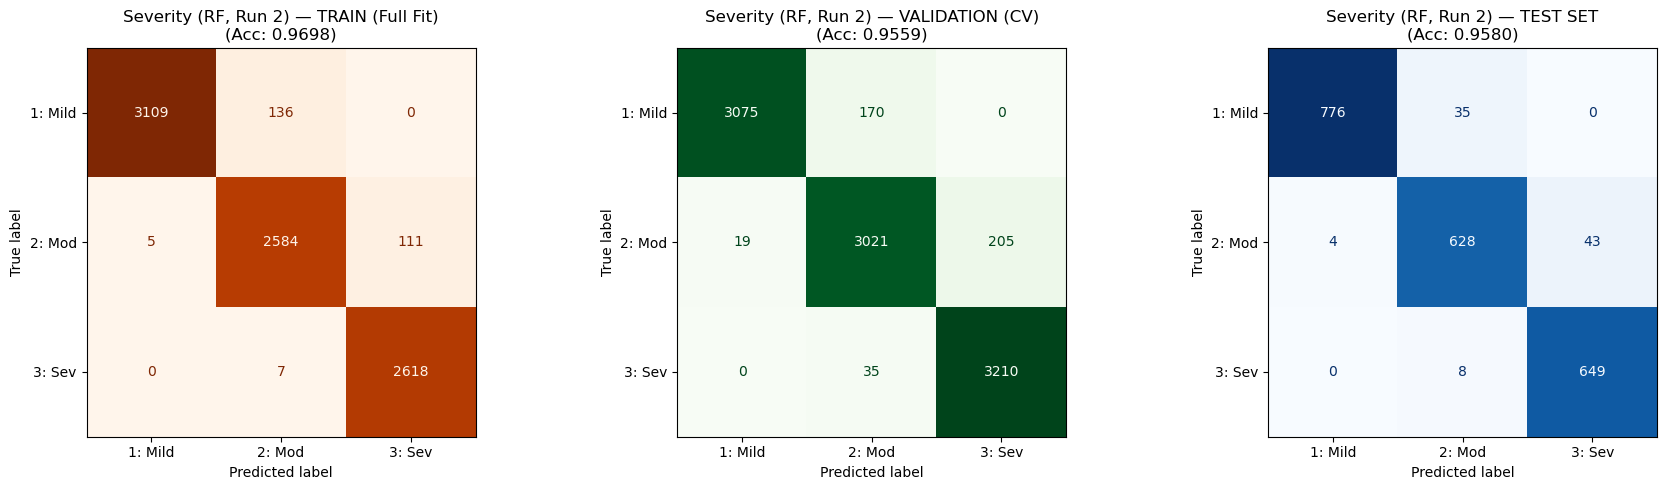


[RF SEVERITY][BEST RUN 2] Generating learning curves (Train vs Validation)...


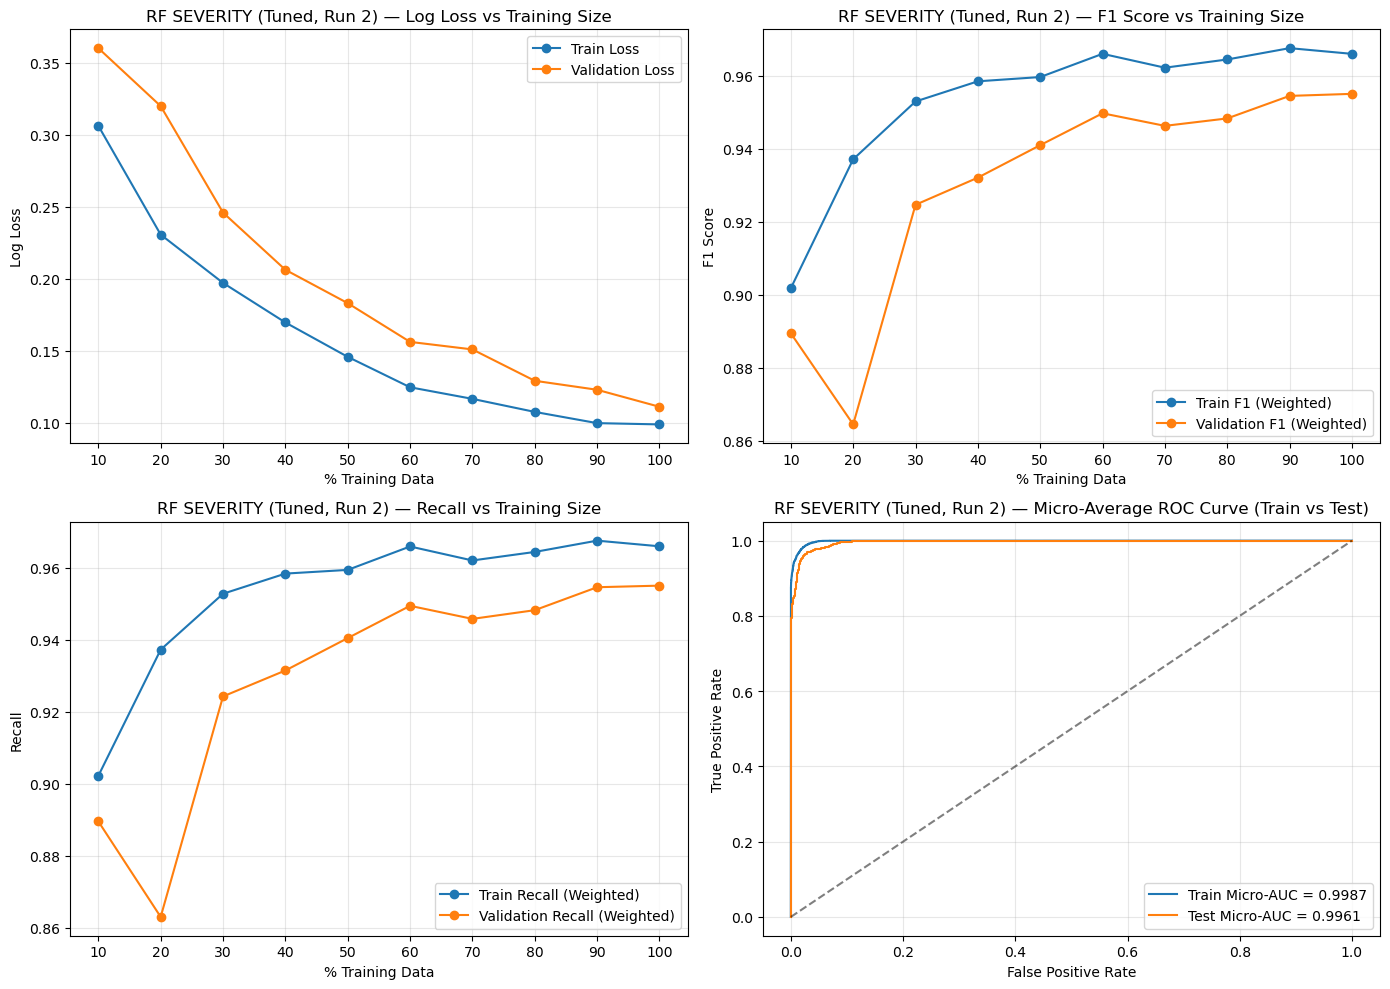

In [21]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Required for the new cross-validation logic
from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV,
    cross_validate, cross_val_predict, train_test_split
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Required for the learning curve SMOTE step (Assuming SMOTE is available in your env)
from imblearn.over_sampling import SMOTE

# ======================== Unified Severity Model - With hyperparameter tuning ========================
# NOTE: The tuning process will use the SMOTE-resampled training data (X_train_smote, y_train_smote)
# but the final evaluation will be on the original data split.
# =====================================================================================================

# --- 1. Tune the models (RandomizedSearchCV) ---

# 10-fold CV (used both for tuning and final validation)
# Use a common cross-validator for all CV steps
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=43)

# Hyperparameter distributions (Randomized Search)
param_distributions = {
    "n_estimators": [50, 100, 200, 300, 500, 800],
    "max_depth": [10, 15, 20, None], # Added None as an option
    "min_samples_leaf": [1, 2, 5, 8, 10, 12],
    "min_samples_split": [2, 5, 10, 20], # Removed 1 as it's invalid for split
    "max_features": ["sqrt", "log2", 0.5, 0.7] # Added 0.7 as an option
}

base_rf = RandomForestClassifier(
    random_state=43,
    n_jobs=-1
)

# Multi-metric scoring for multiclass (Note 'weighted' averages and 'ovr' for ROC AUC)
scoring = {
    "f1": "f1_weighted",
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "recall": "recall_weighted",
    "roc_auc": "roc_auc_ovr_weighted", # Multiclass ROC AUC (One-vs-Rest)
    "log_loss": "neg_log_loss",
}

print("\n========================================================")
print("1. Starting Randomized Search Hyperparameter Tuning (Severity)...")
print("========================================================")

# Run tuning on the SMOTE-resampled training data
random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_distributions,
    n_iter=30, # Number of parameter settings that are sampled
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    refit="f1", # <<< refit on best F1_weighted
    verbose=1,
    random_state=43,
    return_train_score=True
)

t0 = time.time()
# Use the SMOTE training data for tuning
random_search.fit(X_train_smote, y_train_smote)
tuning_time = time.time() - t0
print(f"Total Tuning Time: {tuning_time:.2f} seconds")


# --- 2. Rank them based on f1 ---
cv_results_tuning = random_search.cv_results_
df = pd.DataFrame(cv_results_tuning)

# Flip sign of log_loss
df["mean_test_log_loss_pos"] = -df["mean_test_log_loss"]

# Keep only the columns we care about
cols = [
    "rank_test_f1", # <<< rank by f1
    "param_n_estimators", "param_max_depth", "param_min_samples_leaf",
    "param_min_samples_split", "param_max_features",
    "mean_test_accuracy", "mean_test_precision", "mean_test_recall",
    "mean_test_f1", "mean_test_roc_auc", "mean_test_log_loss_pos", "mean_fit_time"
]

results_table = df[cols].copy()

# Make it a bit prettier: rename columns
results_table.columns = [
    "rank_f1", "n_estimators", "max_depth", "min_samples_leaf",
    "min_samples_split", "max_features", "accuracy", "precision",
    "recall", "f1", "roc_auc", "test_log_loss", "mean_fit_time"
]

# Add run index (1..n)
results_table.insert(0, "run", np.arange(1, len(results_table) + 1))

# Sort by best f1 (rank 1 = best)
results_table = results_table.sort_values("rank_f1")

print("\n[RF SEVERITY][TUNING] Per-run CV table (sorted by F1 rank):")
# Format floats to 4 decimal places
results_table_display = results_table.copy()
float_cols = results_table_display.select_dtypes(include=[np.float64]).columns
for col in float_cols:
    if col != 'mean_fit_time':
        results_table_display[col] = results_table_display[col].apply(lambda x: f"{x:.4f}")
results_table_display['mean_fit_time'] = results_table_display['mean_fit_time'].apply(lambda x: f"{x:.2f}")

print(results_table_display.to_string(index=False))


# --- 3. Output the best params ---
best_params = random_search.best_params_
print("\n[RF SEVERITY][TUNING] Best parameters found by RandomizedSearchCV:")
print(best_params)
print(f"[RF SEVERITY][TUNING] Best mean CV F1 (Weighted): {random_search.best_score_:.4f}")


# ======================== 4. Run the Best Model 3 Times with 10-Fold CV ========================

print("\n========================================================")
print("4. Final Validation: Running tuned model 3 times (10-fold CV on SMOTE data)...")
print("========================================================")

RUNS = 3
all_runs_metrics = []
best_cv_f1_score = -1
best_run_cv_metrics = {}
best_run_cv_results = None # ADDED: Store full CV results for the best run

for i in range(1, RUNS + 1):
    # Use a different random_state for each run to ensure different results
    current_random_state = 100 + i

    # 1) Build a *fresh* RF with the best hyperparameters and new random state
    rf_run = RandomForestClassifier(
        **best_params,
        random_state=current_random_state,
        n_jobs=-1
    )

    print(f"--> Starting Run {i}...")

    # 2) Perform 10-fold Cross-Validation on the SMOTE training data
    t_start_cv = time.time()
    cv_results = cross_validate(
        estimator=rf_run,
        X=X_train_smote, # Use SMOTE data for internal CV/F1 tracking
        y=y_train_smote, # Use SMOTE data for internal CV/F1 tracking
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        return_train_score=False, # Only need test metrics from CV folds
    )
    cv_total_time = time.time() - t_start_cv

    # Calculate mean metrics across 10 folds
    mean_f1 = np.mean(cv_results['test_f1'])

    metrics = {
        "Run": i,
        "Accuracy": np.mean(cv_results['test_accuracy']),
        "Precision": np.mean(cv_results['test_precision']),
        "Recall": np.mean(cv_results['test_recall']),
        "F1-Score": mean_f1,
        "ROC-AUC": np.mean(cv_results['test_roc_auc']),
        "Train Time (s)": np.mean(cv_results['fit_time']), # Avg fit time per fold
        "Total CV Time (s)": cv_total_time,
        "random_state": current_random_state # Keep track of the random state for the best run
    }
    all_runs_metrics.append(metrics)

    # 5. Track the best run based on the average CV F1-Score (on SMOTE data)
    if mean_f1 > best_cv_f1_score:
        best_cv_f1_score = mean_f1
        # Store full set of CV results/data for later analysis/plots
        best_run_cv_metrics = metrics
        best_run_model_params = rf_run.get_params()
        best_run_cv_results = cv_results # ADDED: Store the full CV results dictionary


# Convert metrics to DataFrame for a nice table
metrics_df = pd.DataFrame(all_runs_metrics)

# Display the table for the 3 runs (CV Average Metrics)
print("\n[RF SEVERITY] Mean 10-Fold CV Performance (3 Independent Runs on SMOTE Data):")
metrics_df_display = metrics_df.drop(columns=['random_state']).copy()
float_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for col in float_cols:
    metrics_df_display[col] = metrics_df_display[col].apply(lambda x: f"{x:.4f}")
time_cols = ['Train Time (s)', 'Total CV Time (s)']
for col in time_cols:
    metrics_df_display[col] = metrics_df_display[col].apply(lambda x: f"{x:.2f}")

print(metrics_df_display.to_string(index=False))

# Calculate and display the average metrics across the 3 runs
avg_metrics = metrics_df[float_cols + ['Train Time (s)', 'Total CV Time (s)']].mean()
print("\n[RF SEVERITY] Average Metrics Across the 3 Runs:")

avg_table_data = {
    "Metric": avg_metrics.index,
    "Average Value": [f"{v:.4f}" if m in float_cols else f"{v:.2f}" for m, v in avg_metrics.items()]
}
avg_metrics_df = pd.DataFrame(avg_table_data)
print(avg_metrics_df.to_string(index=False))

# ======================== 5. Finalize and Plot Best Run Results ========================

if best_run_cv_metrics:
    best_run_index = best_run_cv_metrics["Run"]
    best_run_f1 = best_run_cv_metrics["F1-Score"]

    print(f"\n========================================================")
    print(f"5. Analyzing Best CV Run (Run {best_run_index}) with Avg CV F1: {best_run_f1:.4f}")
    print(f"========================================================")

    # 1. Train the best model on the FULL SMOTE training set
    final_best_rf = RandomForestClassifier(**best_run_model_params)
    # The random state is critical for reproducibility
    final_best_rf.random_state = best_run_cv_metrics["random_state"]
    t_start_train = time.time()
    # Use SMOTE data for final training as per tuning logic
    final_best_rf.fit(X_train_smote, y_train_smote)
    final_train_time = time.time() - t_start_train

    # 2. Evaluate on BOTH the ORIGINAL TRAIN and TEST sets

    # --- Predictions for ORIGINAL TRAIN set (Full Fit) ---
    y_pred_train_best = final_best_rf.predict(X_train_all_enc) # Renamed to y_pred_train_full below
    proba_train_best = final_best_rf.predict_proba(X_train_all_enc)

    # --- Predictions for TEST set (Hold-out) ---
    t_start_eval = time.time()
    y_pred_test_best = final_best_rf.predict(X_test_all_enc) # Renamed to y_pred_test below
    proba_test_best = final_best_rf.predict_proba(X_test_all_enc)
    final_eval_time = time.time() - t_start_eval

    # Define classes for label_binarize (used in Multiclass ROC AUC)
    classes = [1, 2, 3]

    # ============================================================
    # --- CALCULATE TRAIN, VALIDATION, AND TEST METRICS (For Gold Standard Table) ---
    # ============================================================
    cv_results = best_run_cv_results # Use the full CV results from the best run

    # Train Metrics (Full Fit on Original Data)
    tr_acc = accuracy_score(y_train_all, y_pred_train_best)
    tr_prec = precision_score(y_train_all, y_pred_train_best, average='weighted', zero_division=0)
    tr_rec = recall_score(y_train_all, y_pred_train_best, average='weighted', zero_division=0)
    tr_f1 = f1_score(y_train_all, y_pred_train_best, average='weighted', zero_division=0)
    y_train_bin = label_binarize(y_train_all, classes=classes)
    tr_auc = roc_auc_score(y_train_bin, proba_train_best, multi_class='ovr', average='weighted')

    # Test Metrics (Hold-out)
    te_acc = accuracy_score(y_test_all, y_pred_test_best)
    te_prec = precision_score(y_test_all, y_pred_test_best, average='weighted', zero_division=0)
    te_rec = recall_score(y_test_all, y_pred_test_best, average='weighted', zero_division=0)
    te_f1 = f1_score(y_test_all, y_pred_test_best, average='weighted', zero_division=0)
    y_test_bin = label_binarize(y_test_all, classes=classes)
    te_auc = roc_auc_score(y_test_bin, proba_test_best, multi_class='ovr', average='weighted')

    # Renaming variables for the Gold Standard format (Times)
    train_time_rf_sev = final_train_time
    eval_time_rf_sev = final_eval_time


    # ============================================================
    # 3. PRINT COMPARISON TABLE (The "Gold Standard" Format) (MODIFIED)
    # ============================================================

    print("\n" + "="*85)
    print(f"{'METRIC':<15} | {'TRAIN (Full Fit)':<18} | {'VALIDATION (10-Fold)':<20} | {'TEST (Hold-out)':<18}")
    print("-" * 85)
    print(f"{'Accuracy':<15} | {tr_acc:<18.4f} | {cv_results['test_accuracy'].mean():<20.4f} | {te_acc:<18.4f}")
    print(f"{'Precision':<15} | {tr_prec:<18.4f} | {cv_results['test_precision'].mean():<20.4f} | {te_prec:<18.4f}")
    print(f"{'Recall':<15} | {tr_rec:<18.4f} | {cv_results['test_recall'].mean():<20.4f} | {te_rec:<18.4f}")
    print(f"{'F1 Score':<15} | {tr_f1:<18.4f} | {cv_results['test_f1'].mean():<20.4f} | {te_f1:<18.4f}")
    print(f"{'ROC AUC':<15} | {tr_auc:<18.4f} | {cv_results['test_roc_auc'].mean():<20.4f} | {te_auc:<18.4f}")
    print("=" * 85)
    print(f"Total Training Time: {train_time_rf_sev:.2f}s")
    print(f"Total Testing Time:  {eval_time_rf_sev:.2f}s")


    # ============================================================
    # 4. Confusion Matrices (Train vs Validation vs Test) (MODIFIED)
    # ============================================================
    labels = [1, 2, 3]
    display_labels = ['1: Mild', '2: Mod', '3: Sev']
    fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5)) 

    # --- Matrix 1: TRAIN (Memorization / Full Fit) ---
    cm_train = confusion_matrix(y_train_all, y_pred_train_best, labels=labels)
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=display_labels)
    disp_train.plot(ax=axes_cm[0], values_format='d', colorbar=False, cmap='Oranges')
    axes_cm[0].set_title(f"Severity (RF, Run {best_run_index}) — TRAIN (Full Fit)\n(Acc: {tr_acc:.4f})")

    clean_params = best_run_model_params.copy()
    current_random_state = clean_params.pop('random_state', None)

    # --- Matrix 2: VALIDATION (Honest / Cross-Validation) ---
    # Use cross_val_predict on SMOTE data
    print("\nGenerating CV Predictions for Matrix...")
    # NOTE: Need a fresh RF classifier for cross_val_predict to ensure correct internal state
    rf_cv_predict = RandomForestClassifier(
         **clean_params,
         random_state=best_run_cv_metrics["random_state"]
    )
    
    y_pred_cv = cross_val_predict(rf_cv_predict, X_train_smote, y_train_smote, cv=cv, n_jobs=-1)

    # The CM uses the SMOTE labels as the ground truth for this validation step
    cm_cv = confusion_matrix(y_train_smote, y_pred_cv, labels=labels)
    disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=display_labels)
    disp_cv.plot(ax=axes_cm[1], values_format='d', colorbar=False, cmap='Greens')
    axes_cm[1].set_title(f"Severity (RF, Run {best_run_index}) — VALIDATION (CV)\n(Acc: {cv_results['test_accuracy'].mean():.4f})")

    # --- Matrix 3: TEST (Real World / Hold-Out) ---
    cm_test = confusion_matrix(y_test_all, y_pred_test_best, labels=labels)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=display_labels)
    disp_test.plot(ax=axes_cm[2], values_format='d', colorbar=False, cmap='Blues')
    axes_cm[2].set_title(f"Severity (RF, Run {best_run_index}) — TEST SET\n(Acc: {te_acc:.4f})")

    plt.tight_layout()
    plt.show()

        # ============================================================
    # 5. Learning Curves & Line Graphs (vs. Training Size)
    #    -> Loss, F1, Recall: TRAIN vs VALIDATION
    #    -> ROC: TRAIN vs TEST (unchanged)
    # ============================================================
    train_fracs = np.linspace(0.1, 1.0, 10)
    train_losses, val_losses = [], []
    train_f1s, val_f1s = [], []
    train_recalls, val_recalls = [], []

    print(f"\n[RF SEVERITY][BEST RUN {best_run_index}] "
          f"Generating learning curves (Train vs Validation)...")

    # For robust slicing in the loop
    y_train_series = (
        y_train_all if isinstance(y_train_all, (pd.Series, pd.DataFrame))
        else pd.Series(y_train_all)
    )

    for frac in train_fracs:
        # 1. Subset the ORIGINAL training data
        n = max(1, int(len(X_train_all_enc) * frac))
        X_sub_orig = X_train_all_enc[:n]
        y_sub_orig = y_train_series.iloc[:n]

        # 2. Train/Validation split on this subset (stratified)
        X_tr_sub, X_val_sub, y_tr_sub, y_val_sub = train_test_split(
            X_sub_orig,
            y_sub_orig,
            test_size=0.2,
            stratify=y_sub_orig,
            random_state=42
        )

        # 3. Apply SMOTE on the TRAIN portion only
        try:
            smote_loop = SMOTE(random_state=42)
            _, counts = np.unique(y_tr_sub, return_counts=True)
            if counts.min() > 1:
                X_tr_smote, y_tr_smote = smote_loop.fit_resample(X_tr_sub, y_tr_sub)
            else:
                X_tr_smote, y_tr_smote = X_tr_sub, y_tr_sub
        except Exception:
            X_tr_smote, y_tr_smote = X_tr_sub, y_tr_sub

        # 4. Train fresh model with best hyperparams
        local_params = best_run_model_params.copy()
        local_params.pop('random_state', None)

        rf_sub = RandomForestClassifier(
            **local_params,
            random_state=final_best_rf.random_state,  # reuse best run random state
        )
        rf_sub.fit(X_tr_smote, y_tr_smote)

        # 5. Evaluate on TRAIN subset (no SMOTE) and VALIDATION subset
        proba_tr = rf_sub.predict_proba(X_tr_sub)
        pred_tr = rf_sub.predict(X_tr_sub)

        proba_val = rf_sub.predict_proba(X_val_sub)
        pred_val = rf_sub.predict(X_val_sub)

        # Loss
        train_losses.append(log_loss(y_tr_sub, proba_tr))
        val_losses.append(log_loss(y_val_sub, proba_val))

        # F1
        train_f1s.append(
            f1_score(y_tr_sub, pred_tr, average='weighted', zero_division=0)
        )
        val_f1s.append(
            f1_score(y_val_sub, pred_val, average='weighted', zero_division=0)
        )

        # Recall
        train_recalls.append(
            recall_score(y_tr_sub, pred_tr, average='weighted', zero_division=0)
        )
        val_recalls.append(
            recall_score(y_val_sub, pred_val, average='weighted', zero_division=0)
        )

    # --- Plotting ---
    x_vals = train_fracs * 100
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Micro-average ROC for the final model (TRAIN vs TEST) – unchanged
    fpr_tr, tpr_tr, _ = roc_curve(y_train_bin.ravel(), proba_train_best.ravel())
    roc_auc_tr_micro = auc(fpr_tr, tpr_tr)

    fpr_te, tpr_te, _ = roc_curve(y_test_bin.ravel(), proba_test_best.ravel())
    roc_auc_te_micro = auc(fpr_te, tpr_te)


    # 3. Log Loss vs Training Size (Train vs Validation)
    axes[0, 0].plot(x_vals, train_losses, 'o-', label='Train Loss')
    axes[0, 0].plot(x_vals, val_losses, 'o-', label='Validation Loss')
    axes[0, 0].set_title(
        f"RF SEVERITY (Tuned, Run {best_run_index}) — Log Loss vs Training Size"
    )
    axes[0, 0].set_xlabel("% Training Data")
    axes[0, 0].set_ylabel("Log Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_xticks(x_vals)

    # 1. F1 Score vs Training Size (Train vs Validation)
    axes[0, 1].plot(x_vals, train_f1s, 'o-', label='Train F1 (Weighted)')
    axes[0, 1].plot(x_vals, val_f1s, 'o-', label='Validation F1 (Weighted)')
    axes[0, 1].set_title(
        f"RF SEVERITY (Tuned, Run {best_run_index}) — F1 Score vs Training Size"
    )
    axes[0, 1].set_xlabel("% Training Data")
    axes[0, 1].set_ylabel("F1 Score")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xticks(x_vals)

    # 2. Recall vs Training Size (Train vs Validation)
    axes[1, 0].plot(x_vals, train_recalls, 'o-', label='Train Recall (Weighted)')
    axes[1, 0].plot(x_vals, val_recalls, 'o-', label='Validation Recall (Weighted)')
    axes[1, 0].set_title(
        f"RF SEVERITY (Tuned, Run {best_run_index}) — Recall vs Training Size"
    )
    axes[1, 0].set_xlabel("% Training Data")
    axes[1, 0].set_ylabel("Recall")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xticks(x_vals)

    # 4. ROC Curve (Micro-average: TRAIN vs TEST)
    axes[1, 1].plot(fpr_tr, tpr_tr, label=f'Train Micro-AUC = {roc_auc_tr_micro:.4f}')
    axes[1, 1].plot(fpr_te, tpr_te, label=f'Test Micro-AUC = {roc_auc_te_micro:.4f}')
    axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1, 1].set_title(
        f"RF SEVERITY (Tuned, Run {best_run_index}) — Micro-Average ROC Curve (Train vs Test)"
    )
    axes[1, 1].set_xlabel("False Positive Rate")
    axes[1, 1].set_ylabel("True Positive Rate")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("\n[ERROR] No best run data was found to generate plots.")

In [22]:
print("SAVING SEVERITY RESOURCES...")

# 1. Save the Severity Model
# At this point in the code, 'final_best_rf' holds the Severity Random Forest
joblib.dump(final_best_rf, os.path.join(save_path, 'severity_model.pkl'))
print(" - Model saved: severity_model.pkl")

# 2. Save the Severity Preprocessor
# In your code, this is named 'preprocessor' (The ColumnTransformer for severity)
joblib.dump(preprocessor, os.path.join(save_path, 'severity_preprocessor.pkl'))
print(" - Preprocessor saved: severity_preprocessor.pkl")

print("✅ Severity resources secured.")

SAVING SEVERITY RESOURCES...
 - Model saved: severity_model.pkl
 - Preprocessor saved: severity_preprocessor.pkl
✅ Severity resources secured.


## ***Save File***

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os

print("================================================")
print("GENERATING RF DETAILED PROOF OF PREDICTION CSV")
print("================================================")

# 1. Load the Saved RF Models
try:
    path_occ = '../saved_models/detection_model.pkl'
    path_sev = '../saved_models/severity_model.pkl'
    
    rf_occ_loaded = joblib.load(path_occ)
    rf_sev_loaded = joblib.load(path_sev)
    print("✅ Loaded both RF models from disk successfully.")
except FileNotFoundError:
    print("❌ Error: Saved model files not found. Using variables from memory...")
    # Fallback if you just ran the training code
    # Note: 'final_best_rf' likely holds the Severity model if run last.
    # This fallback is risky if variables were overwritten.
    rf_occ_loaded = final_best_rf 
    rf_sev_loaded = final_best_rf 

# 2. Predict Occurrence
print("🔮 Predicting Occurrence on Test Set...")
# X_test_occ_enc should be available from your notebook execution
pred_occ_classes = rf_occ_loaded.predict(X_test_occ_enc)
# Ensure 1D array
pred_occ_classes = pred_occ_classes.flatten().astype(int)

# 3. Predict Severity
print("🔮 Predicting Severity on Test Set...")
# X_test_all_enc should be available from your notebook execution
pred_sev_classes = rf_sev_loaded.predict(X_test_all_enc)
pred_sev_classes = pred_sev_classes.flatten().astype(int)
    
# 4. Create the Proof DataFrame
# Start with test_df to keep original inputs
proof_df = test_df.copy().reset_index(drop=True)

# --- Map Model Output 0/1 -> No/Yes ---
proof_df['Predicted_Occurrence_Str'] = pd.Series(pred_occ_classes).map({0: 'No', 1: 'Yes'})

# --- Map Severity Output 1/2/3 -> Mild/Mod/Sev ---
# RF trained on 1, 2, 3 directly
sev_map_str = {1: 'Mild', 2: 'Moderate', 3: 'Severe'}
proof_df['Predicted_Severity_Raw'] = pd.Series(pred_sev_classes)
proof_df['Predicted_Severity_Str'] = proof_df['Predicted_Severity_Raw'].map(sev_map_str)

# --- Logic Correction: Handling Disagreements ---
# If Model said NO, but severity generated a value, we mute it to "N/A"
mask_no_panic = proof_df['Predicted_Occurrence_Str'] == 'No'
proof_df.loc[mask_no_panic, 'Predicted_Severity_Str'] = 'N/A'

# Case 2: Ground Truth Logic
# Ensure 'Panic Attack Severity' is readable
gt_sev_map = {1: 'Mild', 2: 'Moderate', 3: 'Severe'}
proof_df['Actual_Severity_Str'] = proof_df['Panic Attack Severity'].map(gt_sev_map).fillna('None')

# 5. DEFINE COLUMNS
cols_to_show = [
    'Age', 'Gender', 'Family History', 'Personal History', 'Current Stressors', 
    'Symptoms', 'Severity', 'Impact on Life', 'Demographics', 'Medical History', 
    'Psychiatric History', 'Substance Use', 'Coping Mechanisms', 
    'Social Support', 'Lifestyle Factors',
    'Panic Disorder Diagnosis', 'Actual_Severity_Str',
    'Predicted_Occurrence_Str', 'Predicted_Severity_Str'
]

final_cols = [c for c in cols_to_show if c in proof_df.columns]
final_proof_df = proof_df[final_cols]

# 6. Save to CSV (Excel Safe)
filename = "RF_Detailed_Test_Results.csv"
final_proof_df.to_csv(filename, index=False, encoding='utf-8-sig')

print(f"\n✅ SUCCESS! RF Proof file generated: {filename}")
print("-" * 60)
print(f"Total Rows: {len(final_proof_df)}")
print("Preview:")
print(final_proof_df.head())
print("-" * 60)

GENERATING RF DETAILED PROOF OF PREDICTION CSV
✅ Loaded both RF models from disk successfully.
🔮 Predicting Occurrence on Test Set...
🔮 Predicting Severity on Test Set...

✅ SUCCESS! RF Proof file generated: RF_Detailed_Test_Results.csv
------------------------------------------------------------
Total Rows: 2143
Preview:
   Age  Gender Family History Personal History Current Stressors  \
0   58    Male             No               No              High   
1   28    Male            Yes              Yes              High   
2   36  Female            Yes              Yes               Low   
3   20    Male            Yes              Yes              High   
4   60  Female            Yes               No          Moderate   

              Symptoms  Severity Impact on Life Demographics Medical History  \
0            Dizziness      Mild       Moderate        Urban   Heart disease   
1            Dizziness  Moderate    Significant        Urban          Asthma   
2            Dizziness     